## Install Required Libraries

In [15]:
!pip install nibabel -q
!pip install SimpleITK -q
print("Libraries installed!")

Libraries installed!


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import nibabel as nib
from sklearn.cluster import KMeans
from scipy import ndimage
import cv2
from tqdm import tqdm
import time
from skimage.segmentation import find_boundaries
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## Dataset Path Configuration & Exploration


In [7]:
root = Path("/kaggle/input")

print("Top-level folders under /kaggle/input:")

for p in root.iterdir():
    print("  ", p)


Top-level folders under /kaggle/input:
   /kaggle/input/BraTS2020_ValidationData
   /kaggle/input/BraTS2020_TrainingData


In [30]:
DATASET_ROOT = '/kaggle/input/brats20-dataset-training-validation'
TRAINING_ROOT     = "/kaggle/input/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
VALIDATION_ROOT   = "/kaggle/input/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData"

# Get patient directories

training_dirs = sorted([d for d in Path(TRAINING_ROOT).iterdir() if d.is_dir()])

validation_dirs = sorted([d for d in Path(VALIDATION_ROOT).iterdir() if d.is_dir()])



print(f"BraTS2020 DATASET SUMMARY")
print(f"Training Patients:   {len(training_dirs)}")
print(f"Validation Patients: {len(validation_dirs)}")
print(f"Total Patients:      {len(training_dirs) + len(validation_dirs)}")




print("\nFirst 5 Training Patients:")

for i, patient_dir in enumerate(training_dirs[:5], 1):
    
    files = list(patient_dir.glob('*.nii'))
    
    print(f"  {i}. {patient_dir.name:<30} ({len(files)} files)")



first_patient = training_dirs[0]

print(f"\nFiles in {first_patient.name}:")

for file in sorted(first_patient.glob('*.nii')):
    
    file_size = file.stat().st_size / (1024*1024)  # MB
    
    print(f"  • {file.name:<40} ({file_size:.1f} MB)")

BraTS2020 DATASET SUMMARY
Training Patients:   369
Validation Patients: 125
Total Patients:      494

First 5 Training Patients:
  1. BraTS20_Training_001           (5 files)
  2. BraTS20_Training_002           (5 files)
  3. BraTS20_Training_003           (5 files)
  4. BraTS20_Training_004           (5 files)
  5. BraTS20_Training_005           (5 files)

Files in BraTS20_Training_001:
  • BraTS20_Training_001_flair.nii           (17.0 MB)
  • BraTS20_Training_001_seg.nii             (8.5 MB)
  • BraTS20_Training_001_t1.nii              (17.0 MB)
  • BraTS20_Training_001_t1ce.nii            (17.0 MB)
  • BraTS20_Training_001_t2.nii              (17.0 MB)


### Visualize Sample Patient Data


Visualizing first training patient...


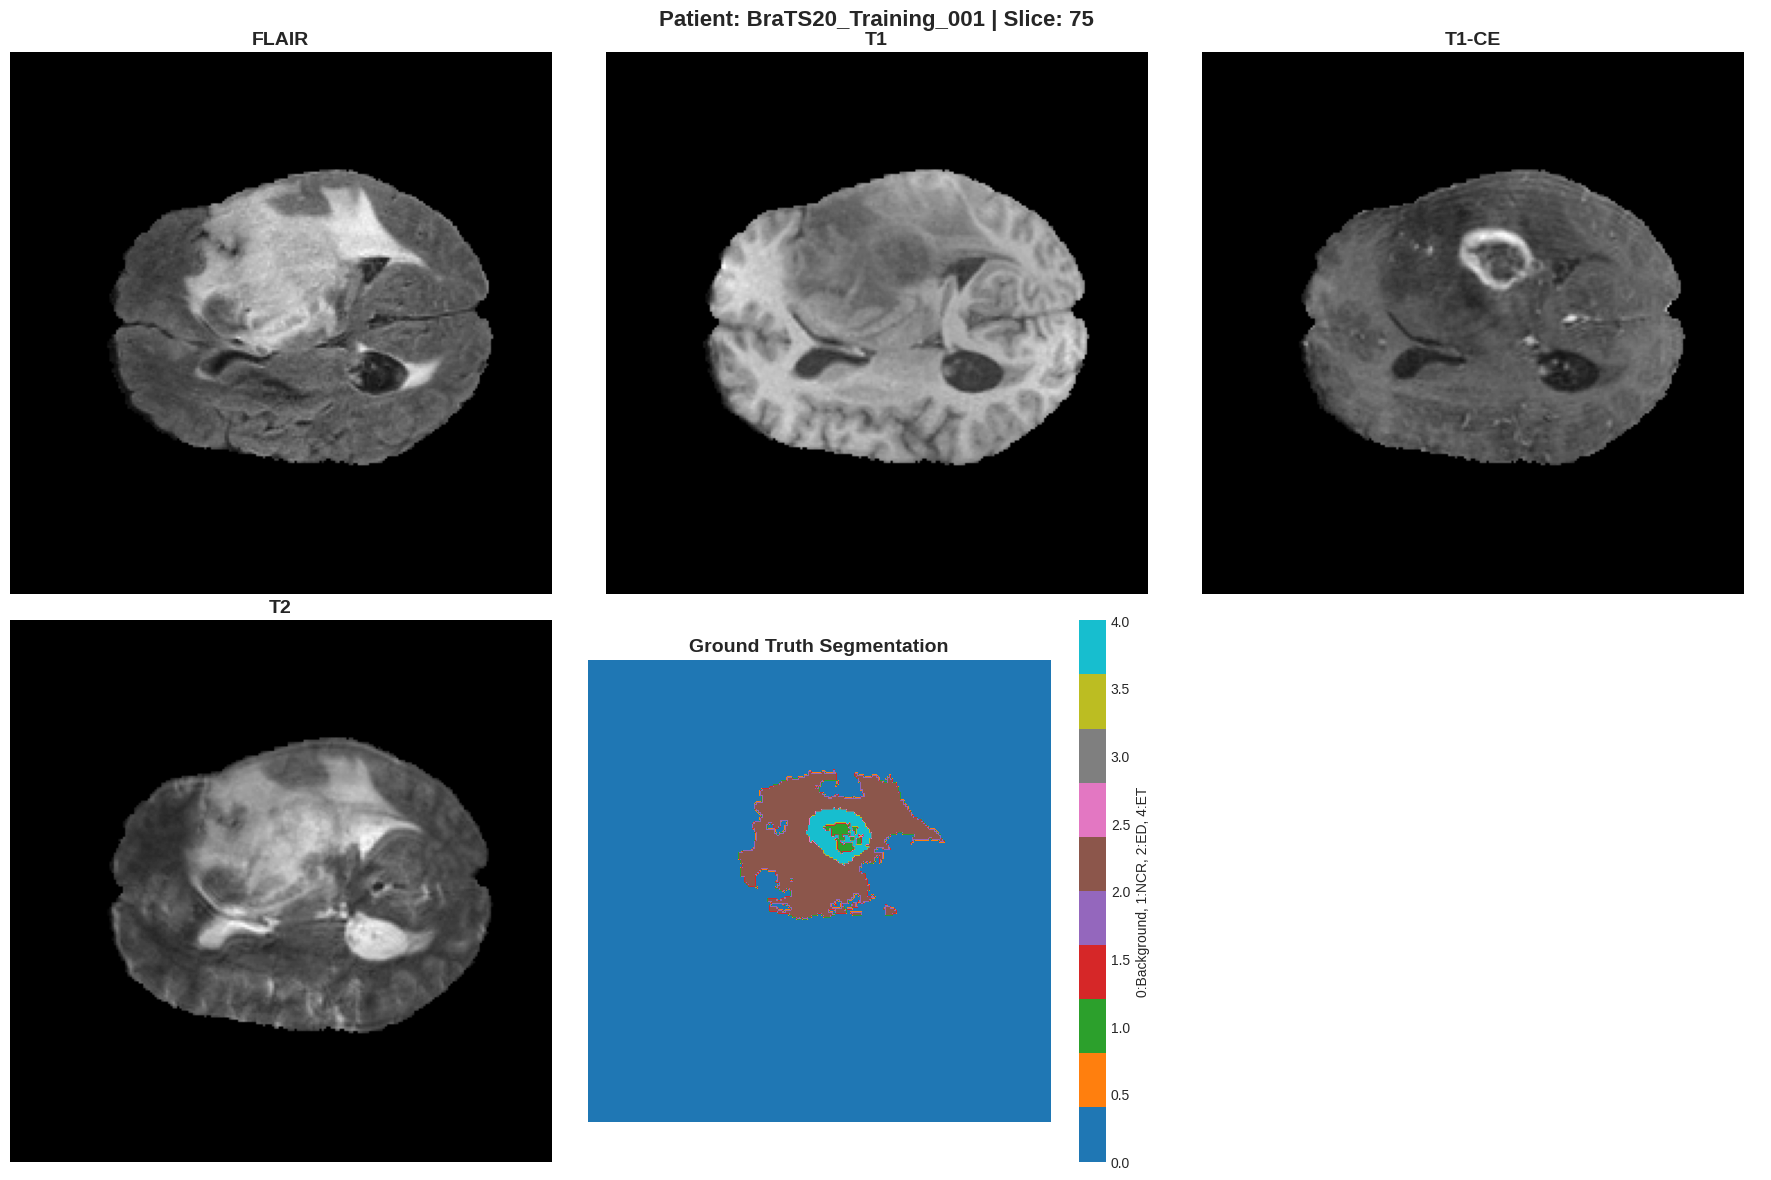

In [31]:
# Visualize all 4 modalities + segmentation for a patient

def visualize_patient_modalities(patient_dir, slice_idx=None):
    
    patient_id = patient_dir.name
    
    # Define modalities
    modalities = ['flair', 't1', 't1ce', 't2', 'seg']
    images = {}
    

    for mod in modalities:
        
        filepath = patient_dir / f"{patient_id}_{mod}.nii"
        
        if filepath.exists():
            img = nib.load(str(filepath))
            volume = img.get_fdata()

            
            # Get middle slice if not specified
            if slice_idx is None:
                
                # Find slice with most brain tissue
                slice_sums = [np.sum(volume[:, :, i] > 0) for i in range(volume.shape[2])]
                
                slice_idx = np.argmax(slice_sums)
            
            images[mod] = volume[:, :, slice_idx]
        else:
            images[mod] = None
    
 
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    fig.suptitle(f'Patient: {patient_id} | Slice: {slice_idx}', 
                 
                 fontsize=16, fontweight='bold')

    
    # modalities
    modality_names = {
        'flair': 'FLAIR',
        't1': 'T1',
        't1ce': 'T1-CE',
        't2': 'T2',
        'seg': 'Ground Truth Segmentation'
    }


    
    positions = [(0,0), (0,1), (0,2), (1,0), (1,1)]
    
    for idx, (mod, name) in enumerate(modality_names.items()):
        
        if idx < len(positions):
            row, col = positions[idx]
            
            if images[mod] is not None:
                
                if mod == 'seg':
                    
                    # Udiscrete colormap for segmentation
                    im = axes[row, col].imshow(images[mod], cmap='tab10', vmin=0, vmax=4)
                    
                    plt.colorbar(im, ax=axes[row, col], 
                               label='0:Background, 1:NCR, 2:ED, 4:ET')
                    
                else:
                    
                    axes[row, col].imshow(images[mod], cmap='gray')
                
                axes[row, col].set_title(name, fontsize=14, fontweight='bold')
                axes[row, col].axis('off')
                
            else:
                axes[row, col].text(0.5, 0.5, f'{name}\nNot Available', 
                                   ha='center', va='center', fontsize=12)
                
                axes[row, col].axis('off')
    
    # Hide last subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    
    plt.show()
    
    return images, slice_idx

# Vfirst patient
print("\nVisualizing first training patient...")
images, slice_idx = visualize_patient_modalities(training_dirs[0])

## Wu et al. (2007) K-means Segmentation Class

In [19]:
class WuKMeansBraTSSegmentation:


    def __init__(self, n_clusters: int = 3, random_state: int = 42):
        self.n_clusters = n_clusters
        self.random_state = random_state

    

    # Data loading and normalisation

    def load_nifti_slice(self, filepath: str, slice_idx: int | None = None):
        
        # Load a 2D slice from a NIfTI volume.
        img = nib.load(str(filepath))
        
        volume = img.get_fdata()


        
        if slice_idx is None:
            
            # Use slice with most non-zero voxels
            slice_sums = np.sum(volume > 0, axis=(0, 1))
            
            slice_idx = int(np.argmax(slice_sums))

        slice_2d = volume[:, :, slice_idx]
        
        return slice_2d, slice_idx

    

    def normalize_image(self, image: np.ndarray):

        brain_mask = image > 0

        if not np.any(brain_mask):
            return image.astype(np.uint8), brain_mask

        brain_pixels = image[brain_mask]
        p2, p98 = np.percentile(brain_pixels, (2, 98))

        image_clipped = np.clip(image, p2, p98)
        
        norm = (image_clipped - p2) / (p98 - p2 + 1e-8)
        norm = (norm * 255.0).astype(np.uint8)

        return norm, brain_mask



    
    # Gray -> RGB -> CIELab
    
    def gray_to_pseudocolor(self, gray_uint8: np.ndarray) -> np.ndarray:
        
        """
        Map a 0–255 grayscale image to RGB using a standard colormap.
        """
        
        color_bgr = cv2.applyColorMap(gray_uint8, cv2.COLORMAP_JET)
        
        color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)
        
        return color_rgb



    def rgb_to_cielab(self, rgb_uint8: np.ndarray):
        
        """
        Convert RGB image to CIELab.
        """
        
        lab = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2LAB)
        
        L, a, b = cv2.split(lab)
        
        return L.astype(np.float32), a.astype(np.float32), b.astype(np.float32)



    
    # Features + K-means in (a*, b*)
   
    def build_ab_features(self, a: np.ndarray, b: np.ndarray, brain_mask: np.ndarray):
        
        """Prepare (a*, b*) feature vectors for K-means, restricted to brain."""
        
        h, w = a.shape
        
        features = np.stack([a, b], axis=-1)
        
        flat_features = features.reshape(-1, 2)
        
        flat_mask = brain_mask.reshape(-1)


        
        brain_indices = np.where(flat_mask)[0]
        
        brain_features = flat_features[brain_indices]

        
        return brain_features, brain_indices, (h, w)


    

    def run_kmeans(self, brain_features: np.ndarray) -> KMeans:
        
        #Run K-means clustering on (a*, b*) features.
        
        kmeans = KMeans(
            
            n_clusters=self.n_clusters,
            
            random_state=self.random_state,
            
            n_init=10,
            
            max_iter=300,
            
        )
        
        kmeans.fit(brain_features)
        
        return kmeans


    
    def reconstruct_label_map(self, kmeans: KMeans, brain_indices, shape):
        
        # Rebuild full label map from K-means labels and brain indices.
        
        h, w = shape
        
        labels_flat = np.full(h * w, fill_value=-1, dtype=np.int32)
        
        labels_flat[brain_indices] = kmeans.labels_
        
        labels = labels_flat.reshape(h, w)
        
        return labels



    
    # Tumour cluster selection

    def select_tumour_cluster(self, L: np.ndarray, labels: np.ndarray, brain_mask: np.ndarray):

        
        brain_area = float(np.sum(brain_mask))
        stats = []

        for c in range(self.n_clusters):
            
            mask_c = (labels == c) & brain_mask
            
            size = int(np.sum(mask_c))
            
            if size == 0:
                
                continue

            size_ratio = size / brain_area
            mean_L = float(np.mean(L[mask_c]))

            
            if 0.005 <= size_ratio <= 0.4:
                size_weight = 1.0
                
            elif 0.001 <= size_ratio < 0.005 or 0.4 < size_ratio <= 0.6:
                size_weight = 0.5
                
            else:
                size_weight = 0.2

            score = mean_L * size_weight

            stats.append(
                dict(
                    cluster_id=c,
                    size=size,
                    size_ratio=size_ratio,
                    mean_L=mean_L,
                    score=score,
                )
            )

        if not stats:
            return None, stats

        stats_sorted = sorted(stats, key=lambda d: d["score"], reverse=True)
        best_cluster_id = stats_sorted[0]["cluster_id"]
        return best_cluster_id, stats_sorted


    
    # Histogram-based refinement on L*

    def histogram_refine_on_L(self, L: np.ndarray, primary_cluster_mask: np.ndarray):
        
        """
        Refine tumour region by histogram-based thresholding on L*.
        Otsu's method approximates the "valley" between peaks in the histogram.
        """
        
        if not np.any(primary_cluster_mask):
            
            return np.zeros_like(primary_cluster_mask, dtype=bool)
    
        # L values only inside the primary cluster
        L_vals = L[primary_cluster_mask]
        
        L_uint8 = np.clip(L_vals, 0, 255).astype(np.uint8)
    
        # Otsu threshold: T is the scalar threshold value
        T, _ = cv2.threshold(L_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
        refined = np.zeros_like(primary_cluster_mask, dtype=bool)
        
        refined[primary_cluster_mask] = L_vals >= T
    
        # Light morphological cleanup
        refined = ndimage.binary_opening(refined, iterations=1)
        
        refined = ndimage.binary_closing(refined, iterations=1)
    
        return refined


    
    # Full pipeline 
    
    def segment_slice(self, filepath: str, slice_idx: int | None = None):

        
        start_time = time.perf_counter()

        # Load slice
        slice_2d, slice_idx = self.load_nifti_slice(filepath, slice_idx)

        # Normalize
        normalized, brain_mask = self.normalize_image(slice_2d)

        # Pseudo-color + CIELab
        pseudo_rgb = self.gray_to_pseudocolor(normalized)
        
        L, a, b = self.rgb_to_cielab(pseudo_rgb)

        
        # Features + K-means on (a*, b*)
        brain_features, brain_indices, shape = self.build_ab_features(a, b, brain_mask)


        
        if brain_features.size == 0:
            
            inference_time = time.perf_counter() - start_time
            
            empty_mask = np.zeros_like(slice_2d, dtype=bool)
            
            return {
                "slice_idx": slice_idx,
                "original": slice_2d,
                "normalized": normalized,
                "pseudo_rgb": pseudo_rgb,
                "L": L,
                "a": a,
                "b": b,
                "labels": np.full_like(slice_2d, fill_value=-1, dtype=np.int32),
                "tumor_mask": empty_mask,
                "tumor_area": 0,
                "cluster_stats": [],
                "tumor_cluster_id": None,
                "inference_time": inference_time,
                "num_params": 0,      # classical algorithm (no trainable params)
                "gflops": np.nan,     # not measured for this non-DL method
            }

        kmeans = self.run_kmeans(brain_features)
        
        labels = self.reconstruct_label_map(kmeans, brain_indices, shape)

        
        # 5Tumour cluster selection
        
        tumour_cluster_id, cluster_stats = self.select_tumour_cluster(L, labels, brain_mask)

        
        if tumour_cluster_id is None:
            
            tumour_mask = np.zeros_like(slice_2d, dtype=bool)
            
        else:
            primary_mask = (labels == tumour_cluster_id) & brain_mask
            
            tumour_mask = self.histogram_refine_on_L(L, primary_mask)
            

        inference_time = time.perf_counter() - start_time

        results = {
            "slice_idx": slice_idx,
            "original": slice_2d,
            "normalized": normalized,
            "pseudo_rgb": pseudo_rgb,
            "L": L,
            "a": a,
            "b": b,
            "labels": labels,
            "tumor_mask": tumour_mask,
            "tumor_area": int(np.sum(tumour_mask)),
            "cluster_stats": cluster_stats,
            "tumor_cluster_id": tumour_cluster_id,
            "inference_time": inference_time,
            "num_params": 0,
            "gflops": np.nan,
        }
        return results


print("Wu et al. (2007) color-based K-means segmentation class (mid-dev) defined.")


Wu et al. (2007) color-based K-means segmentation class (mid-dev) defined.


## Test Segmentation on Single Patient

In [35]:
# segmenter with 3 clusters
segmenter = WuKMeansBraTSSegmentation(n_clusters=3)


# Select first training patient
test_patient = training_dirs[0]

patient_id = test_patient.name

flair_path = test_patient / f"{patient_id}_flair.nii"


print(f"Testing segmentation on: {patient_id}")

print(f"Processing FLAIR image: {flair_path.name}")

print("\nRunning Wu et al. color-based K-means segmentation...")



results = segmenter.segment_slice(str(flair_path))




print("\nSEGMENTATION RESULTS (single patient)\n")


print(f" - Slice Index:        {results['slice_idx']}")

print(f" - Tumour Area:        {results['tumor_area']:,} pixels")

print(f" - Tumour Cluster ID:  {results['tumor_cluster_id']}")

print(f" - Number of Clusters: {segmenter.n_clusters}")

print(f" - Inference Time:     {results['inference_time']:.4f} s")



Testing segmentation on: BraTS20_Training_001
Processing FLAIR image: BraTS20_Training_001_flair.nii

Running Wu et al. color-based K-means segmentation...

SEGMENTATION RESULTS (single patient)

 - Slice Index:        75
 - Tumour Area:        2,841 pixels
 - Tumour Cluster ID:  1
 - Number of Clusters: 3
 - Inference Time:     0.1419 s


## Visualize Segmentation Results

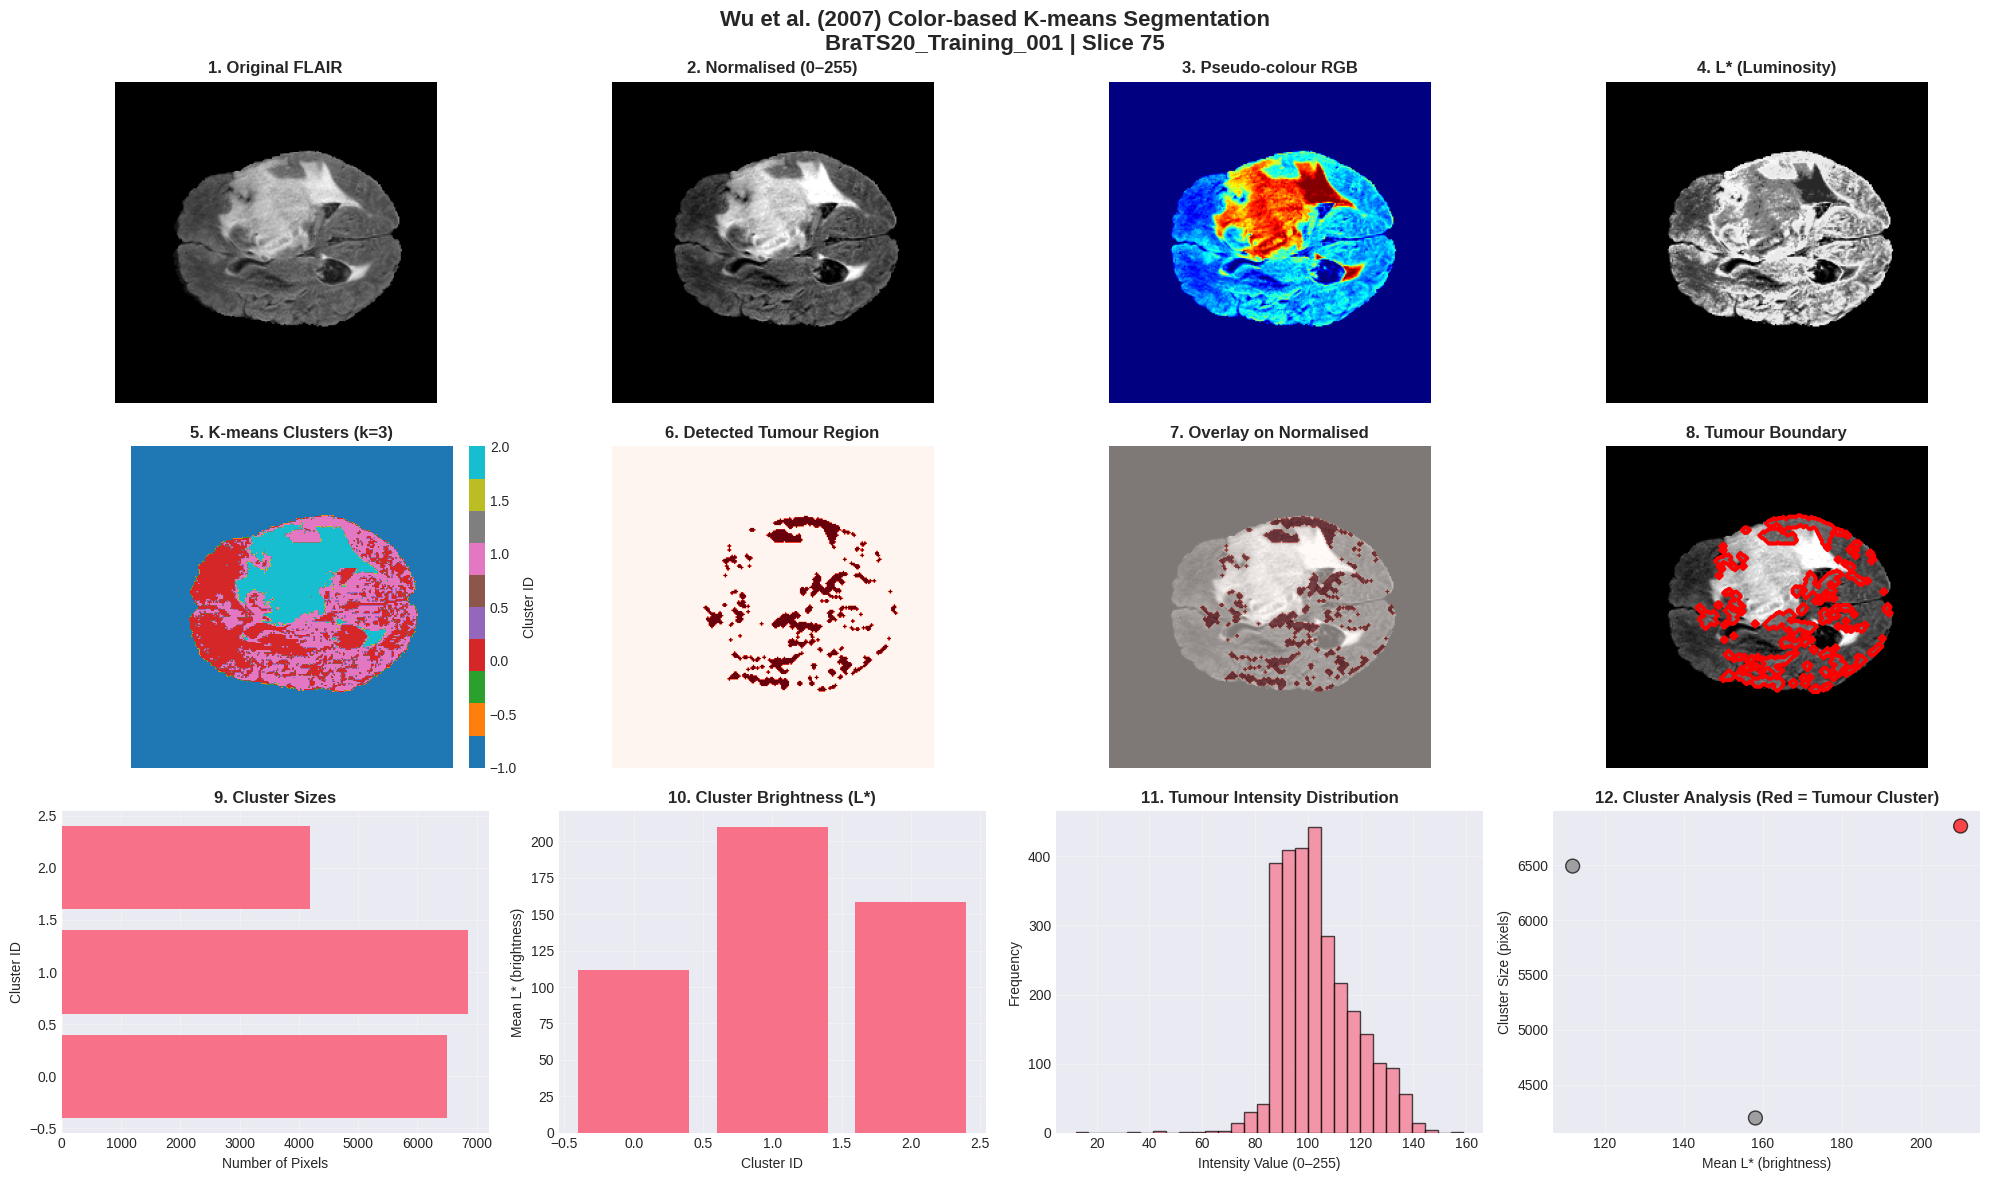

In [28]:
def visualize_segmentation_results(results, patient_id: str):

    
    fig = plt.figure(figsize=(20, 12))
    
    fig.suptitle(
        
        f"Wu et al. (2007) Color-based K-means Segmentation\n"
        
        f"{patient_id} | Slice {results['slice_idx']}",

        fontsize=16,

        fontweight="bold",
    )



    ax1 = plt.subplot(3, 4, 1)

    ax1.imshow(results["original"], cmap="gray")

    ax1.set_title("1. Original FLAIR", fontweight="bold")

    ax1.axis("off")



    ax2 = plt.subplot(3, 4, 2)

    ax2.imshow(results["normalized"], cmap="gray")

    ax2.set_title("2. Normalised (0–255)", fontweight="bold")

    ax2.axis("off")



    ax3 = plt.subplot(3, 4, 3)

    ax3.imshow(results["pseudo_rgb"])

    ax3.set_title("3. Pseudo-colour RGB", fontweight="bold")

    ax3.axis("off")



    ax4 = plt.subplot(3, 4, 4)

    ax4.imshow(results["L"], cmap="gray")

    ax4.set_title("4. L* (Luminosity)", fontweight="bold")

    ax4.axis("off")



    ax5 = plt.subplot(3, 4, 5)

    labels = results["labels"]

    # Exclude -1 (background) when computing k for title
    unique_labels = np.unique(labels)

    k_effective = len(unique_labels[unique_labels >= 0])

    im5 = ax5.imshow(labels, cmap="tab10")

    ax5.set_title(f"5. K-means Clusters (k={k_effective})", fontweight="bold")

    ax5.axis("off")

    plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04, label="Cluster ID")




    ax6 = plt.subplot(3, 4, 6)

    ax6.imshow(results["tumor_mask"], cmap="Reds")

    ax6.set_title("6. Detected Tumour Region", fontweight="bold")

    ax6.axis("off")




    ax7 = plt.subplot(3, 4, 7)

    ax7.imshow(results["normalized"], cmap="gray")

    ax7.imshow(results["tumor_mask"], cmap="Reds", alpha=0.5)

    ax7.set_title("7. Overlay on Normalised", fontweight="bold")

    ax7.axis("off")




    ax8 = plt.subplot(3, 4, 8)

    ax8.imshow(results["normalized"], cmap="gray")

    try:
        
        contours = find_boundaries(results["tumor_mask"], mode="outer")
        
        ax8.contour(contours, colors="red", linewidths=2)
        
    except Exception:
        
        ax8.imshow(results["tumor_mask"], cmap="Reds", alpha=0.3)
        
    ax8.set_title("8. Tumour Boundary", fontweight="bold")

    ax8.axis("off")




    # Cluster statistics and tumour intensity distribution

    cluster_stats = results.get("cluster_stats", [])

    if cluster_stats:
        
        cluster_df = pd.DataFrame(cluster_stats)

        # Cluster sizes
        ax9 = plt.subplot(3, 4, 9)
        
        cluster_df_sorted = cluster_df.sort_values("size", ascending=True)
        
        ax9.barh(cluster_df_sorted["cluster_id"], cluster_df_sorted["size"])
        
        ax9.set_xlabel("Number of Pixels")
        
        ax9.set_ylabel("Cluster ID")
        
        ax9.set_title("9. Cluster Sizes", fontweight="bold")
        
        ax9.grid(True, alpha=0.3)



        # Cluster mean L* (brightness)
        ax10 = plt.subplot(3, 4, 10)
        
        ax10.bar(cluster_df["cluster_id"], cluster_df["mean_L"])
        
        ax10.set_xlabel("Cluster ID")
        
        ax10.set_ylabel("Mean L* (brightness)")
        
        ax10.set_title("10. Cluster Brightness (L*)", fontweight="bold")
        
        ax10.grid(True, alpha=0.3)


        
        # Tumour intensity distribution
        ax11 = plt.subplot(3, 4, 11)
        
        tumour_pixels = results["normalized"][results["tumor_mask"]]

        if tumour_pixels.size > 0:
            
            ax11.hist(tumour_pixels, bins=30, alpha=0.7, edgecolor="black")
            
            ax11.set_xlabel("Intensity Value (0–255)")
            
            ax11.set_ylabel("Frequency")
            
            ax11.set_title("11. Tumour Intensity Distribution", fontweight="bold")
            
            ax11.grid(True, alpha=0.3)
            
        else:
            
            ax11.text(0.5, 0.5, "No tumour pixels", ha="center", va="center")
            
            ax11.axis("off")



        # Cluster analysis: mean L* vs size, highlight tumour cluster
        ax12 = plt.subplot(3, 4, 12)
        
        tumour_cluster_id = results.get("tumor_cluster_id", None)
        
        colours = [
            
            "red" if (tumour_cluster_id is not None and cid == tumour_cluster_id) else "gray"
            for cid in cluster_df["cluster_id"]
        ]

        
        
        ax12.scatter(cluster_df["mean_L"], cluster_df["size"],
                     c=colours, s=100, alpha=0.7, edgecolors="black")
        
        ax12.set_xlabel("Mean L* (brightness)")
        
        ax12.set_ylabel("Cluster Size (pixels)")
        
        ax12.set_title("12. Cluster Analysis (Red = Tumour Cluster)", fontweight="bold")
        
        ax12.grid(True, alpha=0.3)


    else:
        
        ax9 = plt.subplot(3, 4, 9)
        
        ax9.text(0.5, 0.5, "No cluster statistics available",
                 
                 ha="center", va="center")
        
        ax9.axis("off")


    plt.tight_layout()
    plt.show()


visualize_segmentation_results(results, patient_id)


In [36]:
# Evaluation: Dice (DSC), IoU (Jaccard), Normalized Surface Dice (NSD)


def calculate_dice_score(pred: np.ndarray, gt: np.ndarray) -> float:
    
    
    pred = pred.astype(bool)
    
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    
    size_sum = pred.sum() + gt.sum()

    if size_sum == 0:
        return 1.0
    return 2.0 * intersection / size_sum



def calculate_iou(pred: np.ndarray, gt: np.ndarray) -> float:
   
    pred = pred.astype(bool)
    
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    
    union = np.logical_or(pred, gt).sum()

    if union == 0:
        
        return 1.0
        
    return intersection / union



def calculate_normalized_surface_dice(pred: np.ndarray,
                                      gt: np.ndarray,
                                      tolerance: float = 1.0) -> float:
    """
    Normalized Surface Dice (NSD) with a voxel-distance tolerance.
    This measures how close the prediction and ground-truth boundaries are.
    """
    
    pred = pred.astype(bool)
    
    gt = gt.astype(bool)

    if not np.any(pred) and not np.any(gt):
        
        return 1.0

    surface_pred = find_boundaries(pred, mode="outer")
    
    surface_gt = find_boundaries(gt, mode="outer")

    if not np.any(surface_pred) and not np.any(surface_gt):
        
        return 1.0

    
    dist_to_gt = ndimage.distance_transform_edt(~surface_gt)
    
    dist_to_pred = ndimage.distance_transform_edt(~surface_pred)

    tp_pred = surface_pred & (dist_to_gt <= tolerance)
    
    tp_gt = surface_gt & (dist_to_pred <= tolerance)

    tp = tp_pred.sum() + tp_gt.sum()
    
    denom = surface_pred.sum() + surface_gt.sum()

    if denom == 0:
        return 0.0
    return tp / denom


def evaluate_segmentation(patient_dir: Path,
                          results: dict,
                          nsd_tolerance: float = 1.0):
    """
    Evaluate Wu mid-dev segmentation against BraTS ground truth for one slice.
    Returns a dict with DSC, IoU, NSD and the binary ground-truth mask.
    """
    
    patient_id = patient_dir.name
    
    seg_path = patient_dir / f"{patient_id}_seg.nii"

    if not seg_path.exists():
        
        print(f"Ground truth segmentation not available for {patient_id}")
        
        return None

    seg_img = nib.load(str(seg_path))
    
    seg_volume = seg_img.get_fdata()
    
    gt_slice = seg_volume[:, :, results["slice_idx"]]

    # BraTS tumour = any label > 0
    gt_binary = (gt_slice > 0).astype(int)
    
    pred_binary = results["tumor_mask"].astype(int)

    dice = calculate_dice_score(pred_binary, gt_binary)
    
    iou = calculate_iou(pred_binary, gt_binary)
    
    nsd = calculate_normalized_surface_dice(pred_binary, gt_binary,
                                            tolerance=nsd_tolerance)

    eval_results = {
        "patient_id": patient_id,
        "slice_idx": results["slice_idx"],
        "dice": float(dice),
        "iou": float(iou),
        "nsd": float(nsd),
        "gt_binary": gt_binary,
    }


    print(f"\nEvaluation for {patient_id} | Slice {results['slice_idx']}\n")

    print(f"Dice (DSC):            {eval_results['dice']:.4f}")
    
    print(f"IoU (Jaccard):         {eval_results['iou']:.4f}")
    
    print(f"NSD (tol={nsd_tolerance} vox): {eval_results['nsd']:.4f}")


    # visual comparison
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    fig.suptitle(
        f"Ground Truth vs Prediction | Dice: {eval_results['dice']:.4f}",
        
        fontsize=16,
        
        fontweight="bold",
    )

    axes[0].imshow(results["normalized"], cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(eval_results["gt_binary"], cmap="Reds")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(results["tumor_mask"], cmap="Blues")
    axes[2].set_title("Prediction (Wu mid-dev)")
    axes[2].axis("off")

    axes[3].imshow(results["normalized"], cmap="gray")
    axes[3].imshow(eval_results["gt_binary"], cmap="Reds", alpha=0.3)
    axes[3].imshow(results["tumor_mask"], cmap="Blues", alpha=0.3)
    axes[3].set_title("Overlay (Red=GT, Blue=Pred)")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    return eval_results



BATCH PROCESSING - Wu mid-dev (color-based K-means)



Processing patients:   0%|          | 0/20 [00:00<?, ?it/s]


Evaluation for BraTS20_Training_001 | Slice 75

Dice (DSC):            0.0982
IoU (Jaccard):         0.0516
NSD (tol=1.0 vox): 0.2286


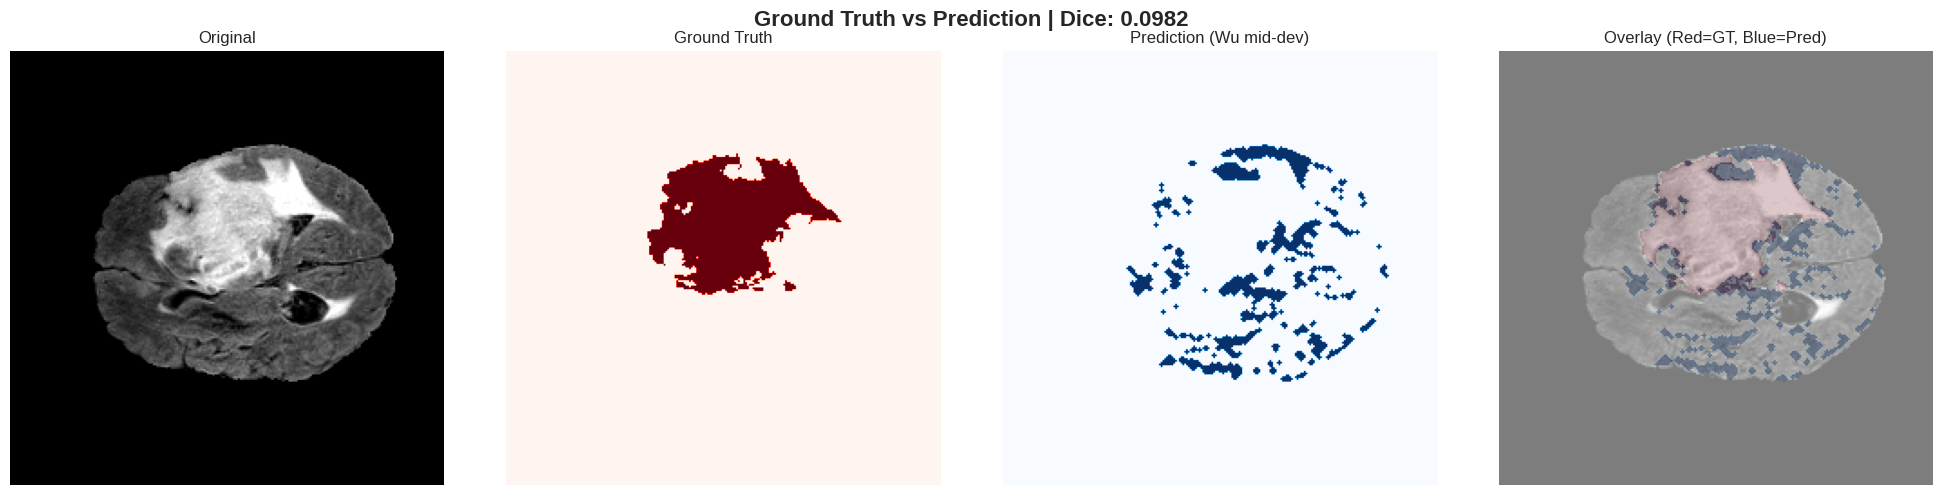

Processing patients:   5%|▌         | 1/20 [00:00<00:14,  1.35it/s]


Evaluation for BraTS20_Training_002 | Slice 66

Dice (DSC):            0.3596
IoU (Jaccard):         0.2192
NSD (tol=1.0 vox): 0.2528


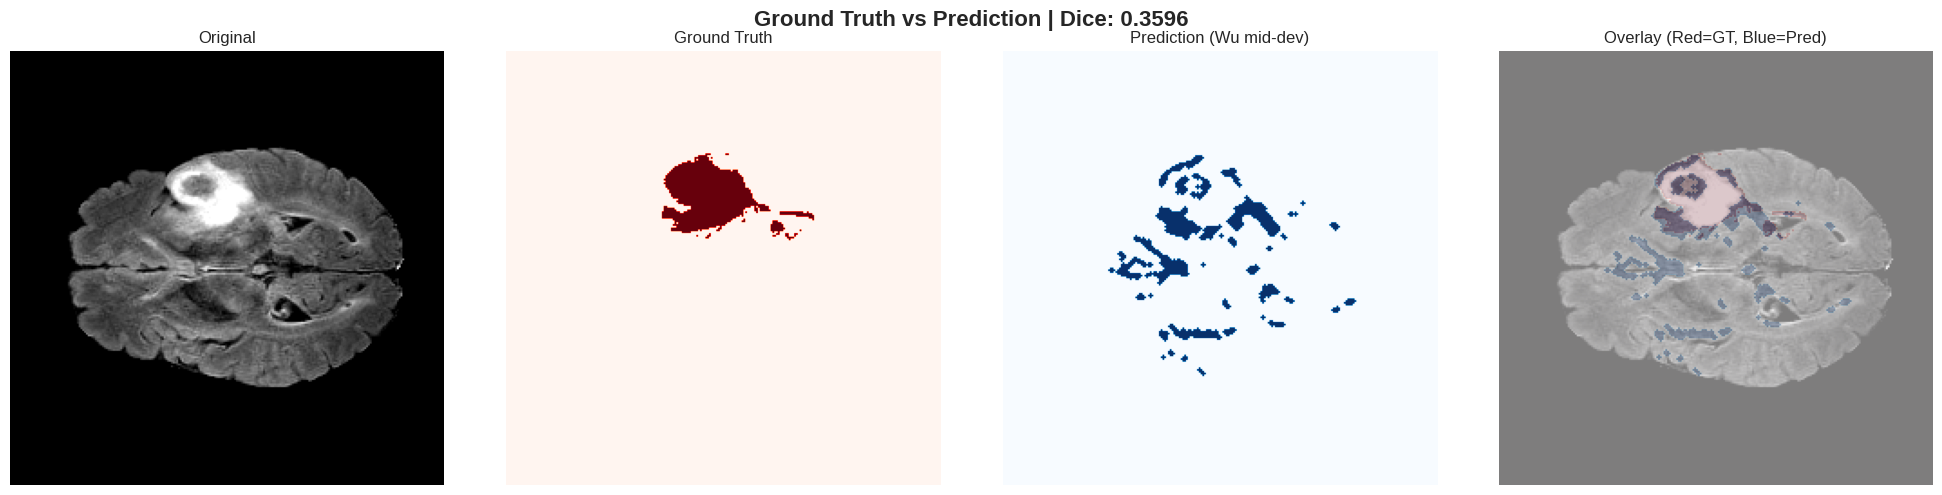

Processing patients:  10%|█         | 2/20 [00:01<00:13,  1.34it/s]


Evaluation for BraTS20_Training_003 | Slice 78

Dice (DSC):            0.0000
IoU (Jaccard):         0.0000
NSD (tol=1.0 vox): 0.0564


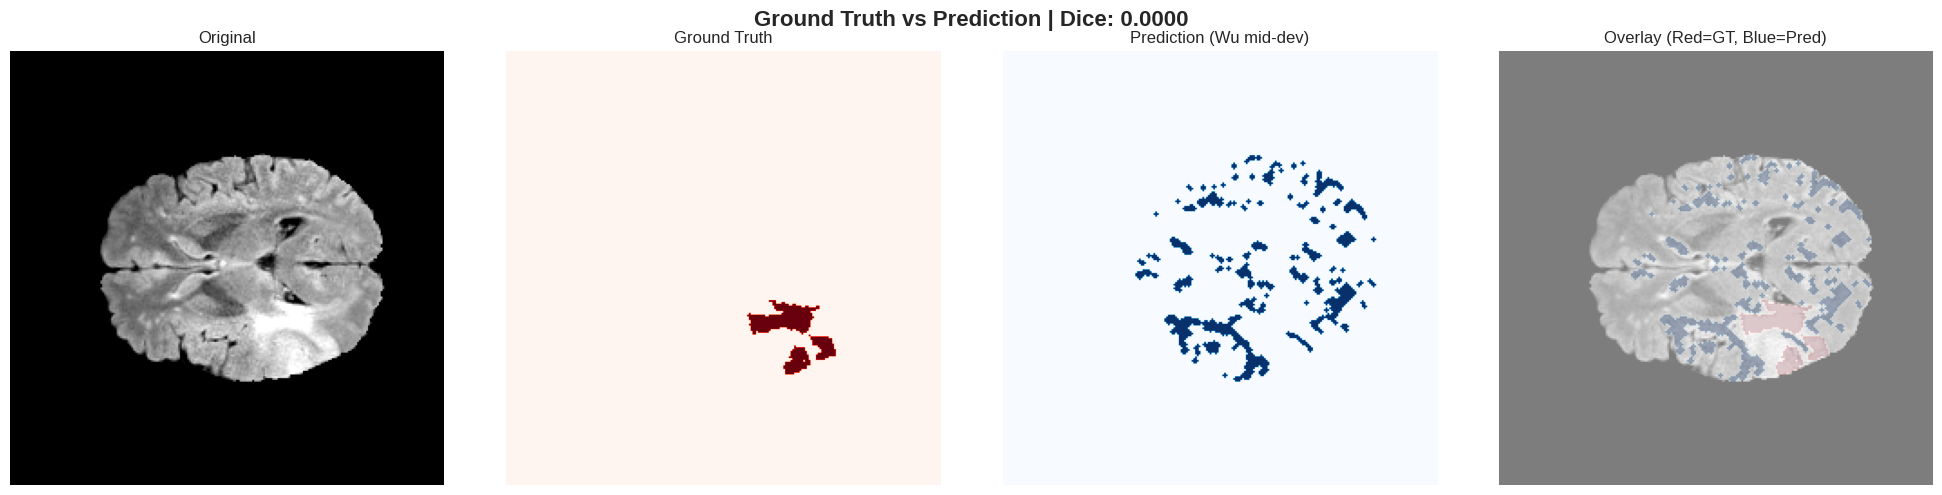

Processing patients:  15%|█▌        | 3/20 [00:02<00:14,  1.19it/s]


Evaluation for BraTS20_Training_004 | Slice 65

Dice (DSC):            0.0341
IoU (Jaccard):         0.0173
NSD (tol=1.0 vox): 0.1127


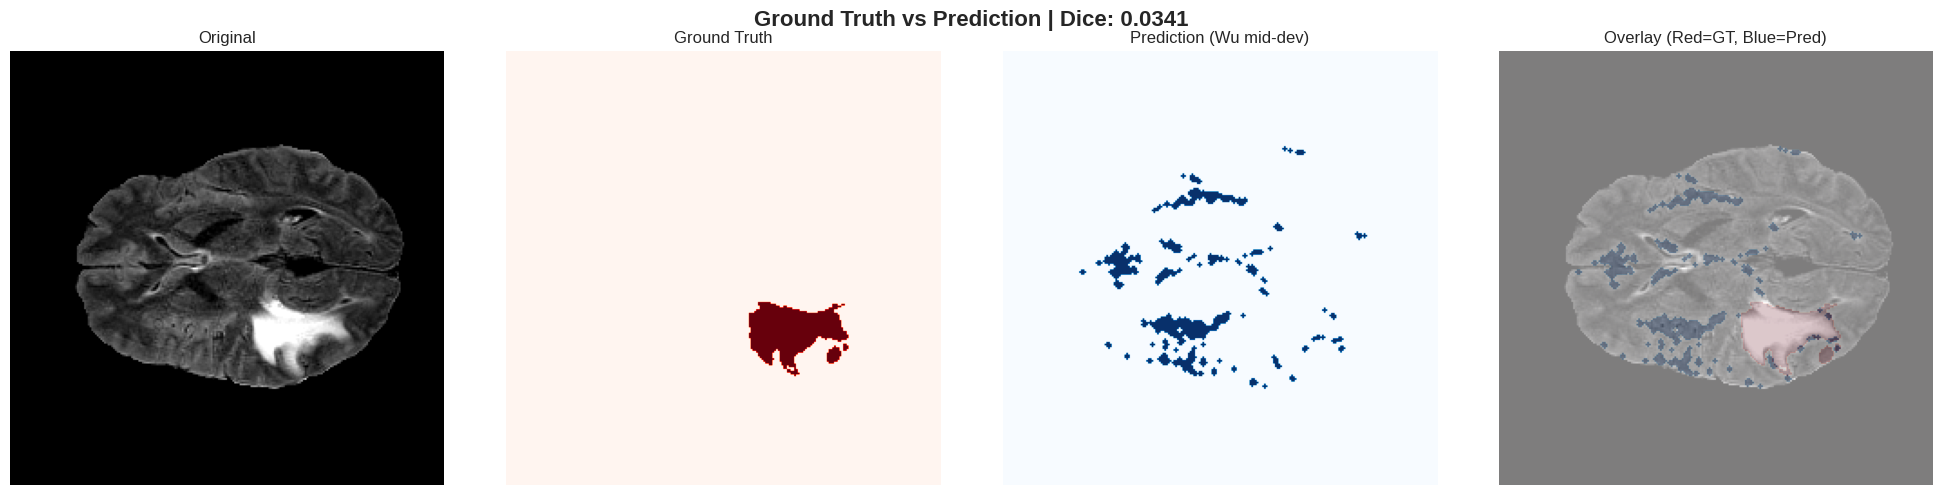

Processing patients:  20%|██        | 4/20 [00:03<00:13,  1.23it/s]


Evaluation for BraTS20_Training_005 | Slice 72

Dice (DSC):            0.0000
IoU (Jaccard):         0.0000
NSD (tol=1.0 vox): 0.0000


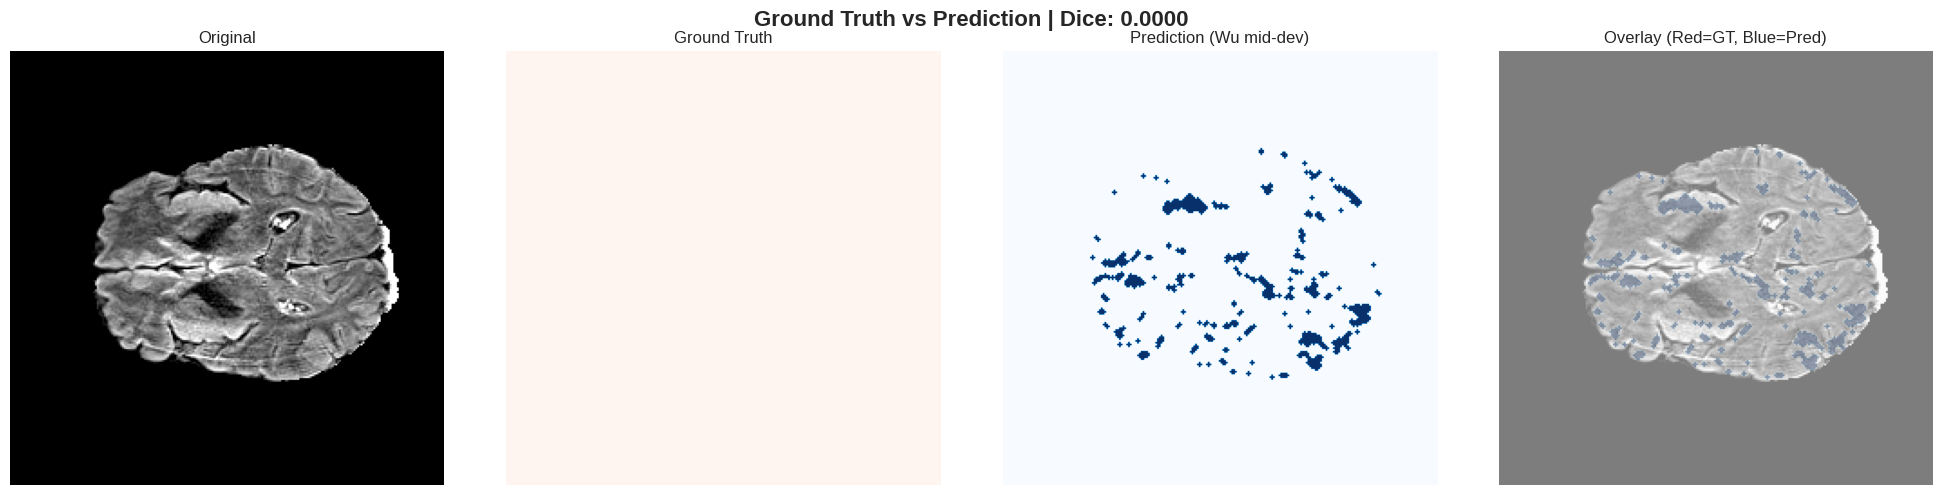

Processing patients:  25%|██▌       | 5/20 [00:03<00:11,  1.26it/s]


Evaluation for BraTS20_Training_006 | Slice 75

Dice (DSC):            0.0522
IoU (Jaccard):         0.0268
NSD (tol=1.0 vox): 0.1820


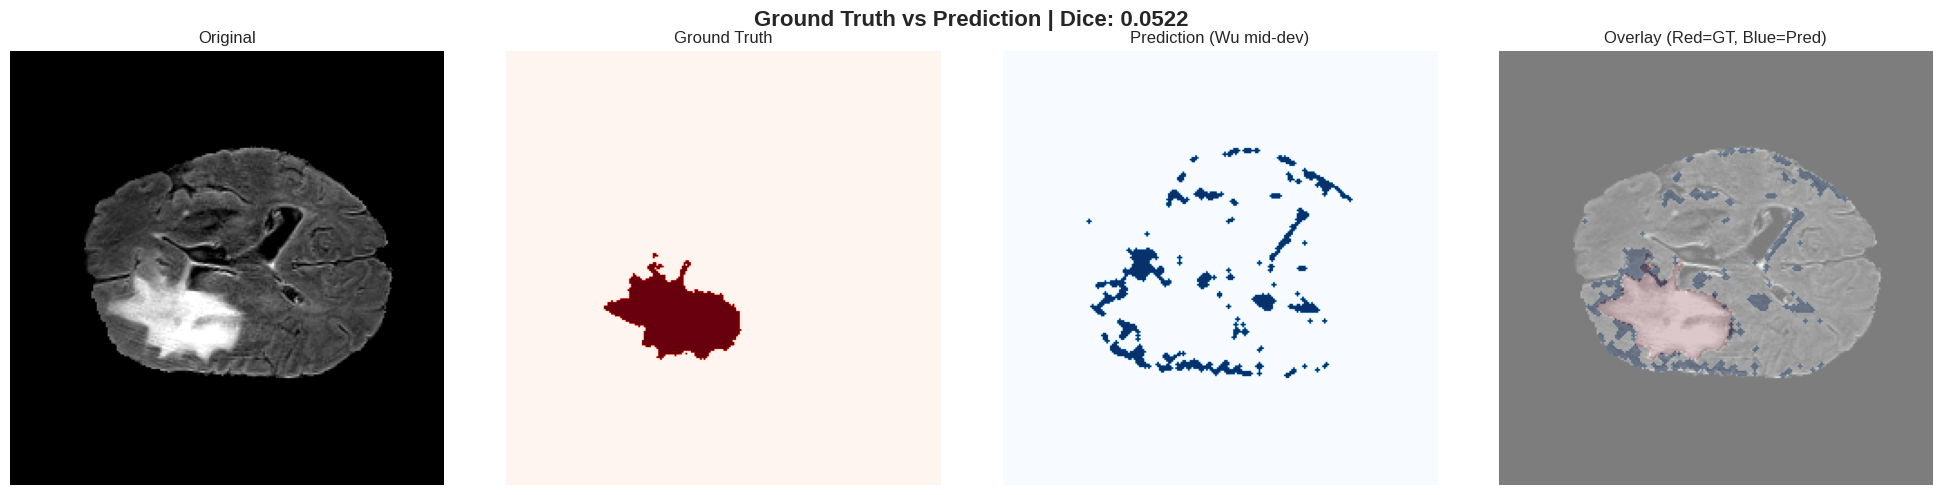

Processing patients:  30%|███       | 6/20 [00:04<00:10,  1.28it/s]


Evaluation for BraTS20_Training_007 | Slice 81

Dice (DSC):            0.0000
IoU (Jaccard):         0.0000
NSD (tol=1.0 vox): 0.0373


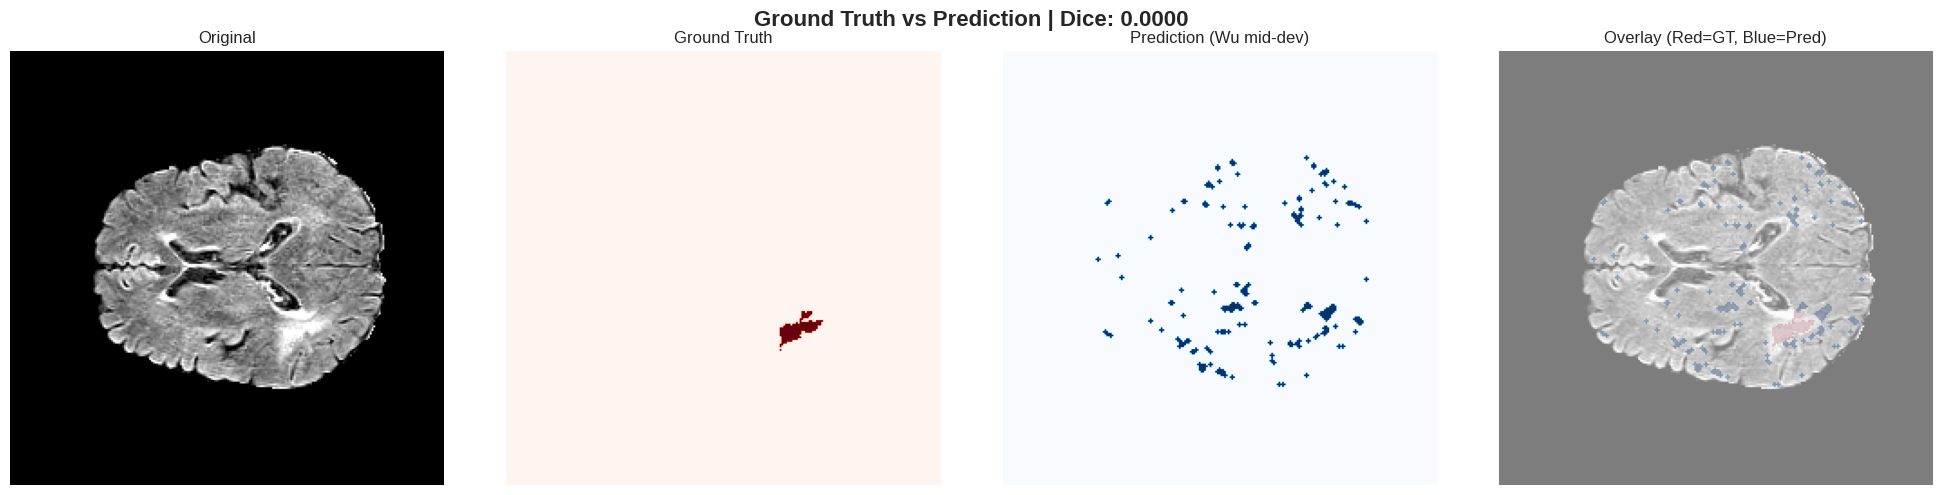

Processing patients:  35%|███▌      | 7/20 [00:05<00:10,  1.30it/s]


Evaluation for BraTS20_Training_008 | Slice 72

Dice (DSC):            0.0000
IoU (Jaccard):         0.0000
NSD (tol=1.0 vox): 0.0000


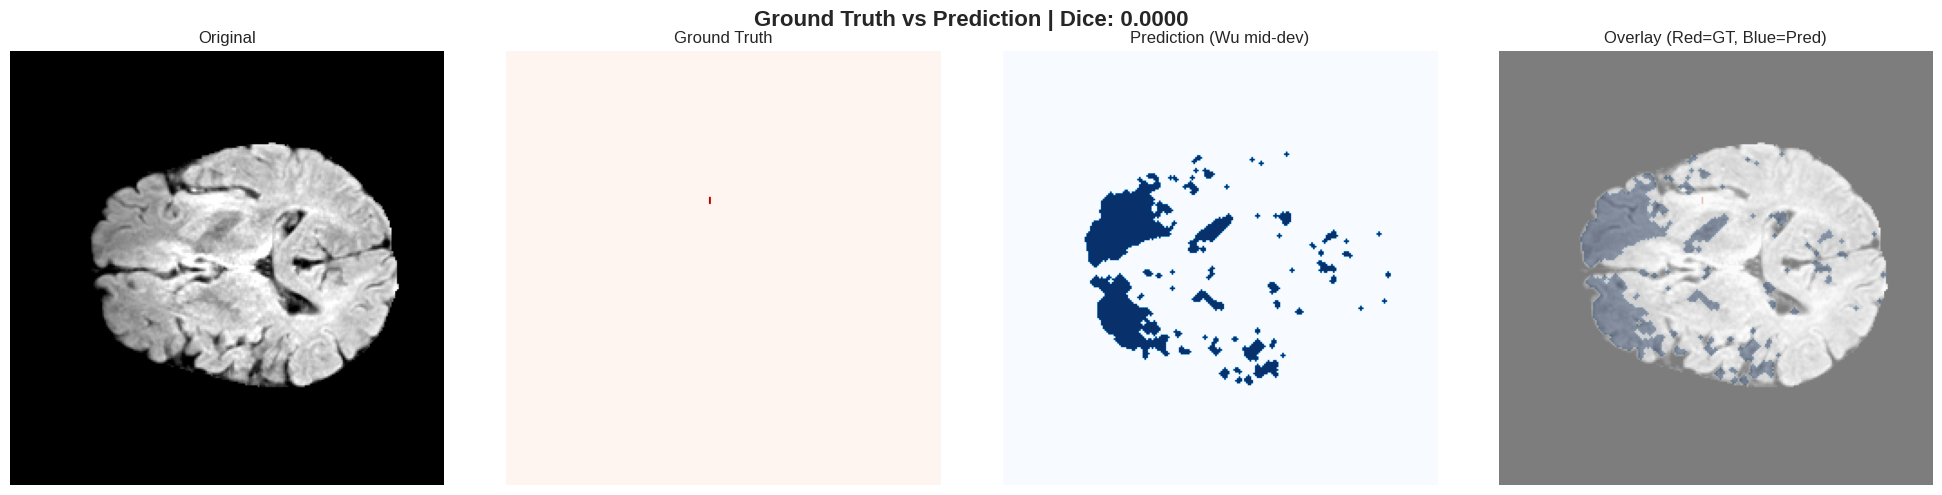

Processing patients:  40%|████      | 8/20 [00:06<00:09,  1.28it/s]


Evaluation for BraTS20_Training_009 | Slice 82

Dice (DSC):            0.0820
IoU (Jaccard):         0.0428
NSD (tol=1.0 vox): 0.2072


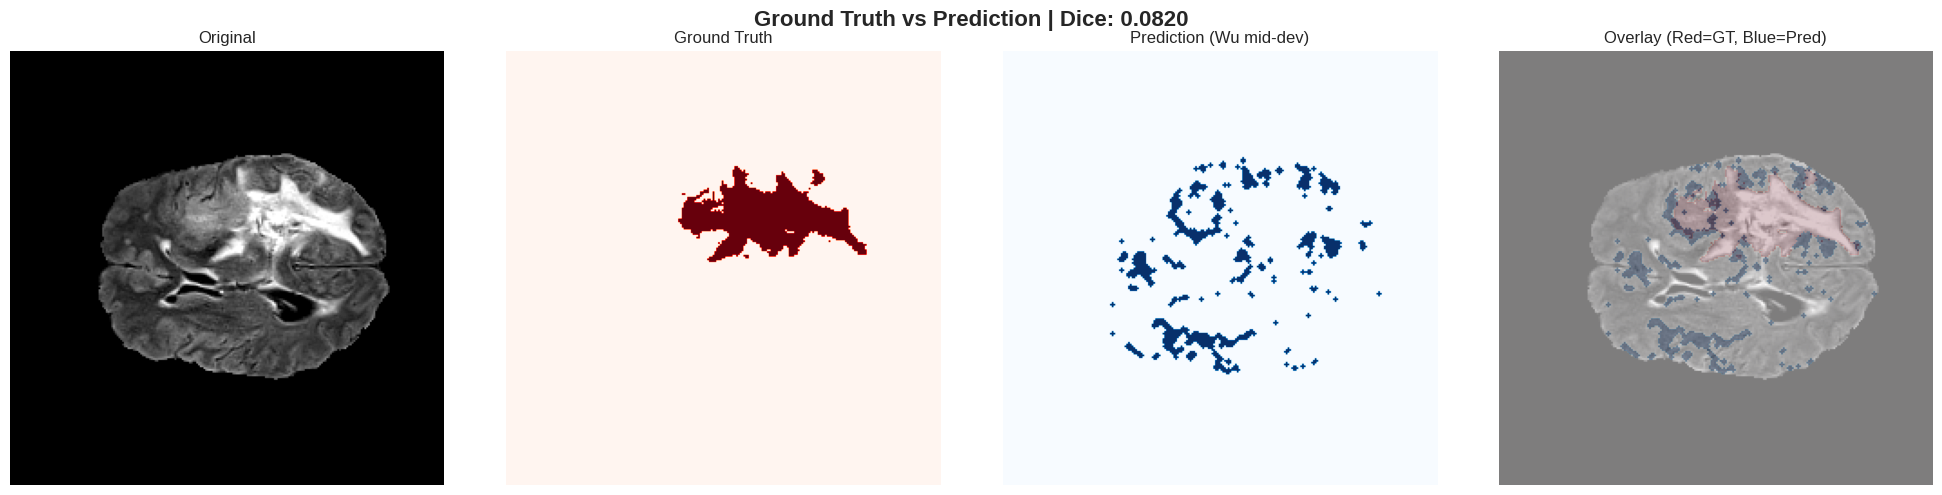

Processing patients:  45%|████▌     | 9/20 [00:07<00:08,  1.30it/s]


Evaluation for BraTS20_Training_010 | Slice 77

Dice (DSC):            0.0872
IoU (Jaccard):         0.0456
NSD (tol=1.0 vox): 0.1389


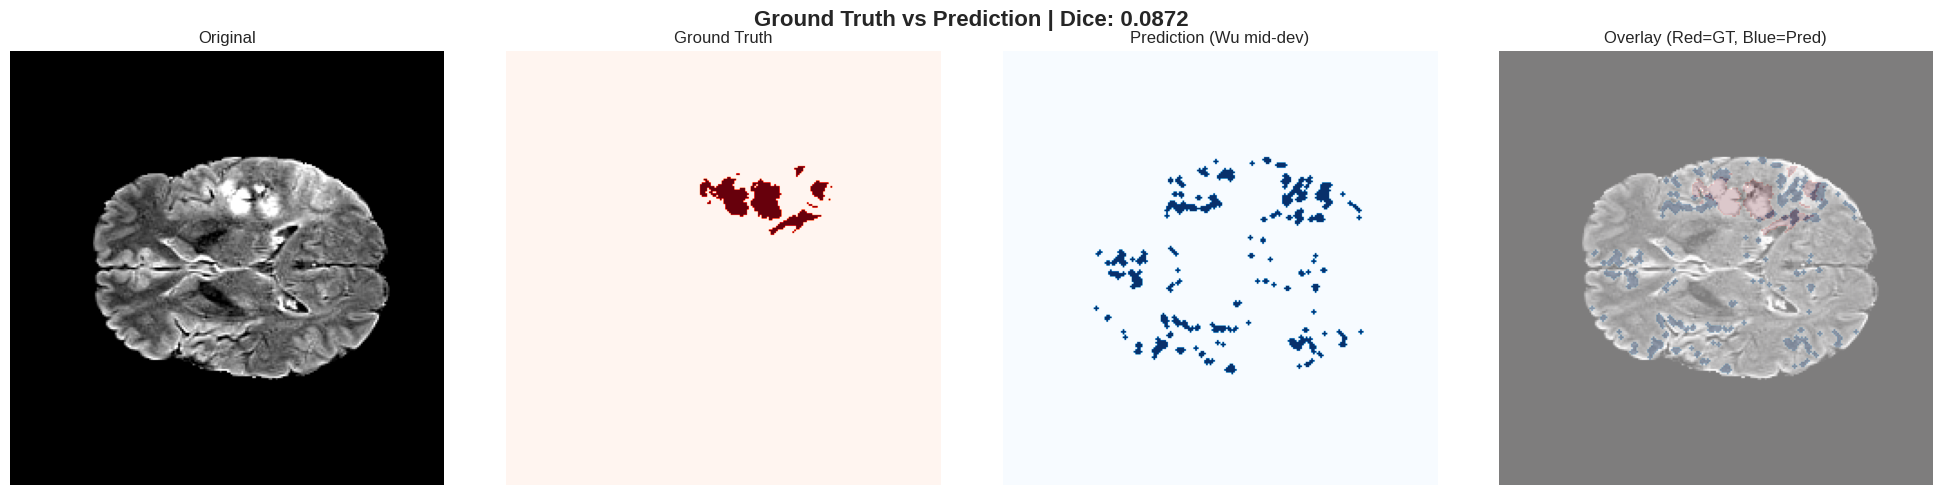

Processing patients:  50%|█████     | 10/20 [00:07<00:07,  1.31it/s]


Evaluation for BraTS20_Training_011 | Slice 77

Dice (DSC):            0.1636
IoU (Jaccard):         0.0891
NSD (tol=1.0 vox): 0.2739


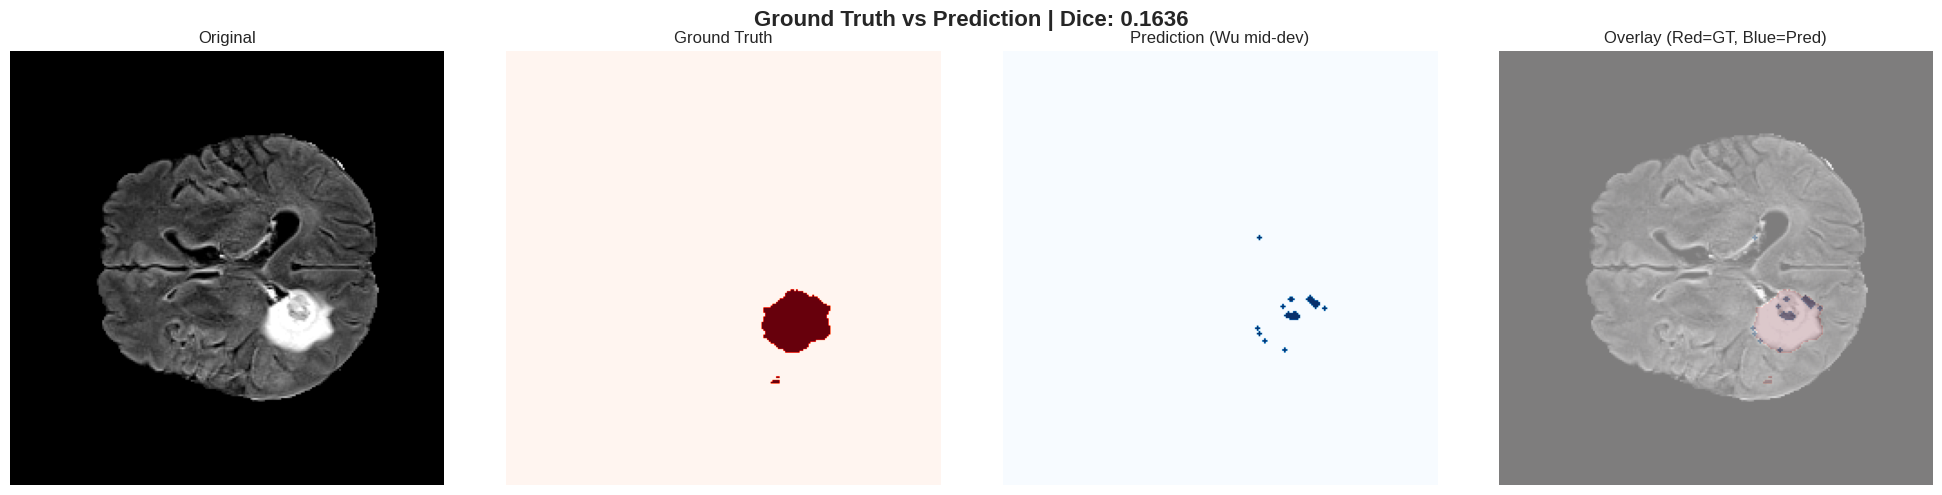

Processing patients:  55%|█████▌    | 11/20 [00:08<00:07,  1.21it/s]


Evaluation for BraTS20_Training_012 | Slice 78

Dice (DSC):            0.1123
IoU (Jaccard):         0.0595
NSD (tol=1.0 vox): 0.0859


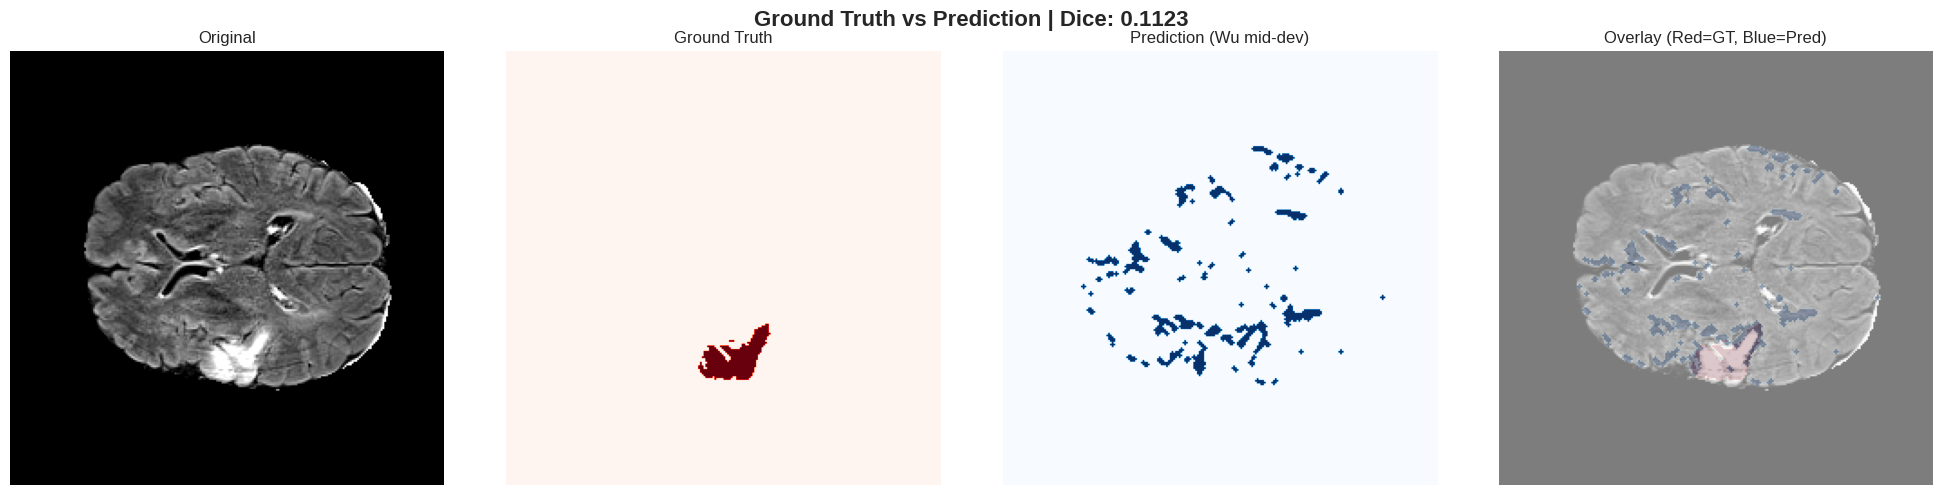

Processing patients:  60%|██████    | 12/20 [00:09<00:06,  1.24it/s]


Evaluation for BraTS20_Training_013 | Slice 80

Dice (DSC):            0.2638
IoU (Jaccard):         0.1519
NSD (tol=1.0 vox): 0.2048


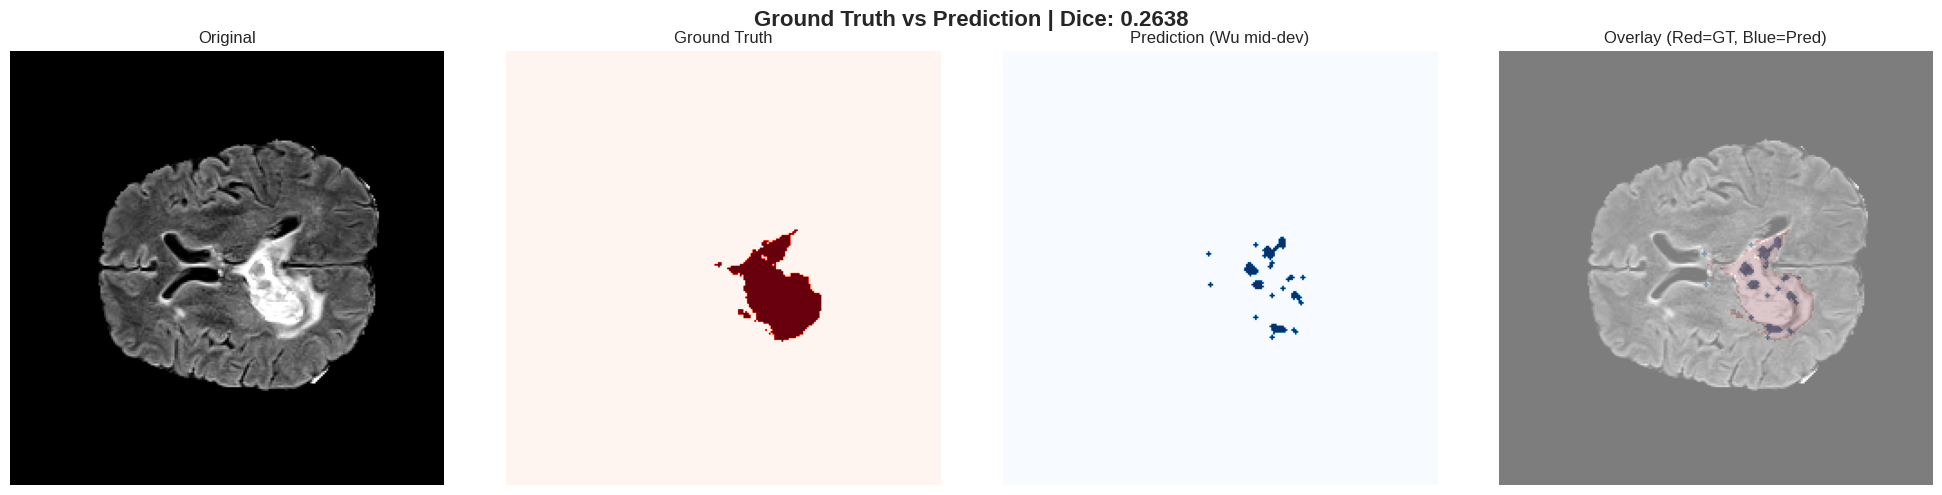

Processing patients:  65%|██████▌   | 13/20 [00:10<00:05,  1.27it/s]


Evaluation for BraTS20_Training_014 | Slice 73

Dice (DSC):            0.1782
IoU (Jaccard):         0.0978
NSD (tol=1.0 vox): 0.1594


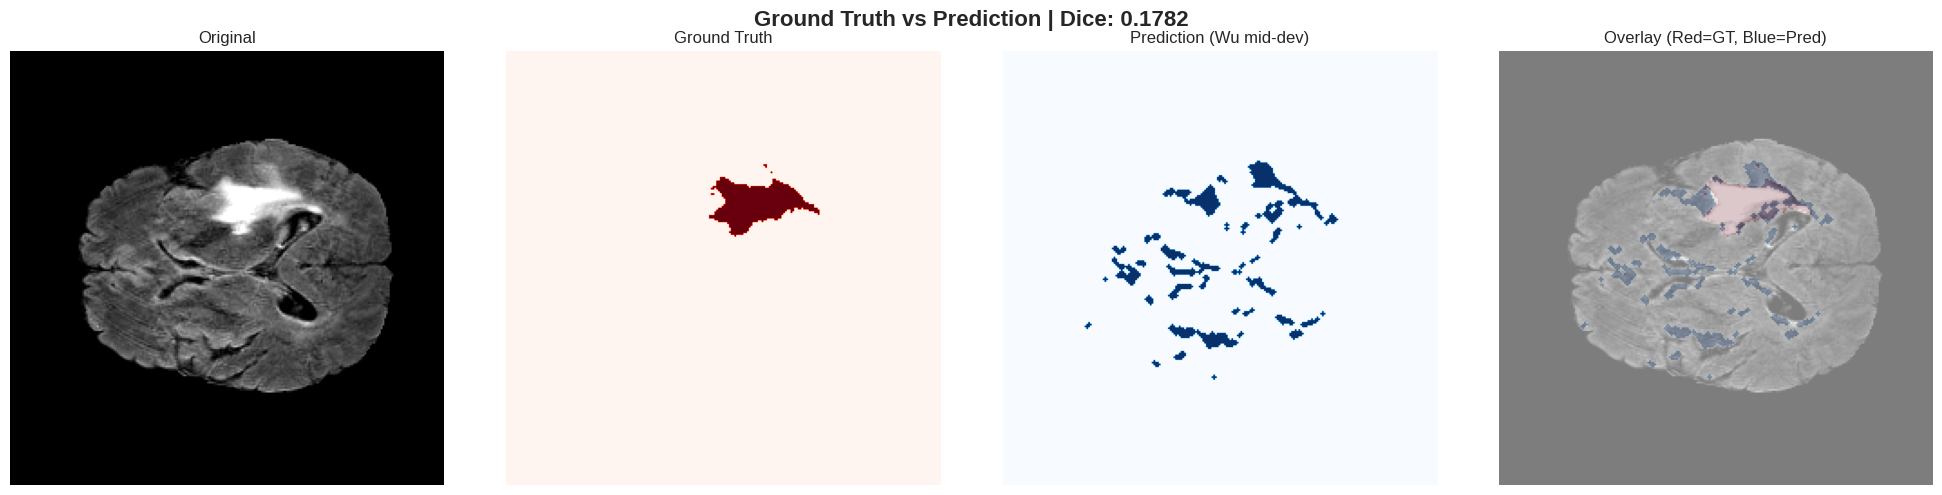

Processing patients:  70%|███████   | 14/20 [00:10<00:04,  1.30it/s]


Evaluation for BraTS20_Training_015 | Slice 72

Dice (DSC):            0.3636
IoU (Jaccard):         0.2222
NSD (tol=1.0 vox): 0.3549


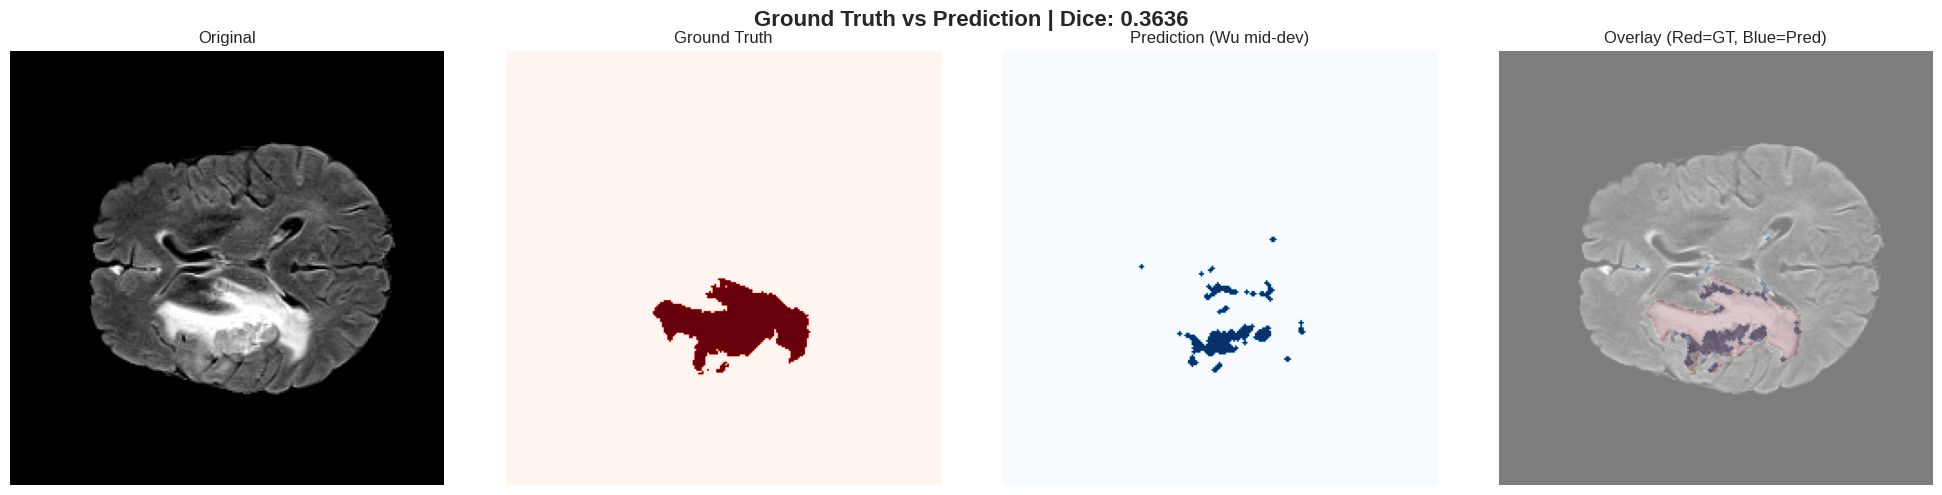

Processing patients:  75%|███████▌  | 15/20 [00:11<00:03,  1.32it/s]


Evaluation for BraTS20_Training_016 | Slice 72

Dice (DSC):            0.3746
IoU (Jaccard):         0.2304
NSD (tol=1.0 vox): 0.5434


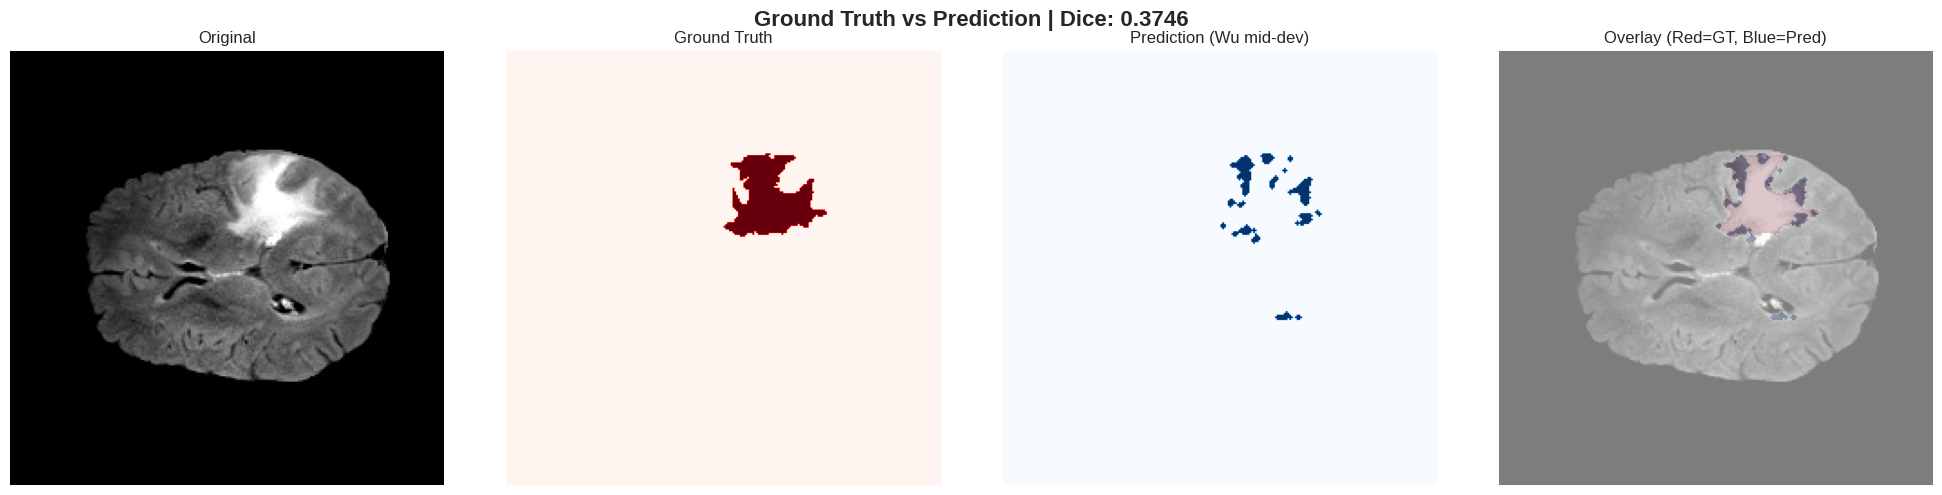

Processing patients:  80%|████████  | 16/20 [00:12<00:03,  1.33it/s]


Evaluation for BraTS20_Training_017 | Slice 71

Dice (DSC):            0.0200
IoU (Jaccard):         0.0101
NSD (tol=1.0 vox): 0.1592


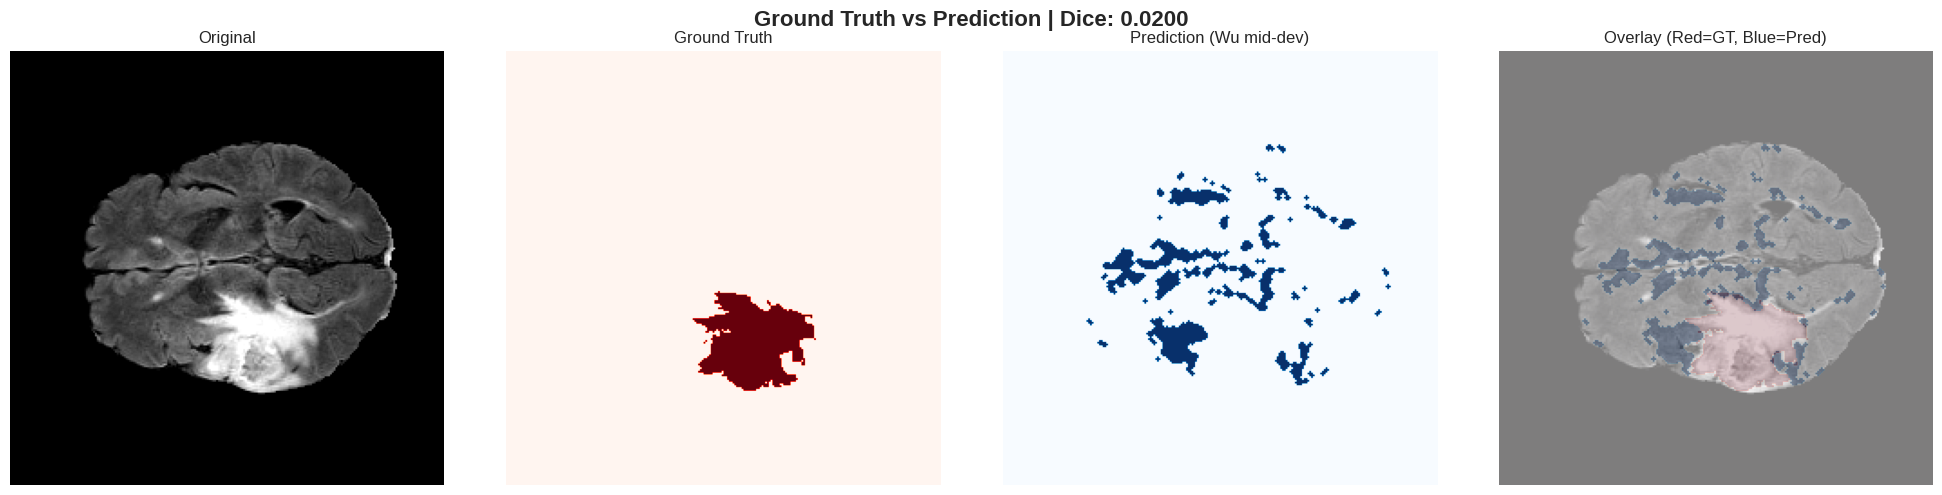

Processing patients:  85%|████████▌ | 17/20 [00:13<00:02,  1.33it/s]


Evaluation for BraTS20_Training_018 | Slice 79

Dice (DSC):            0.2420
IoU (Jaccard):         0.1377
NSD (tol=1.0 vox): 0.3568


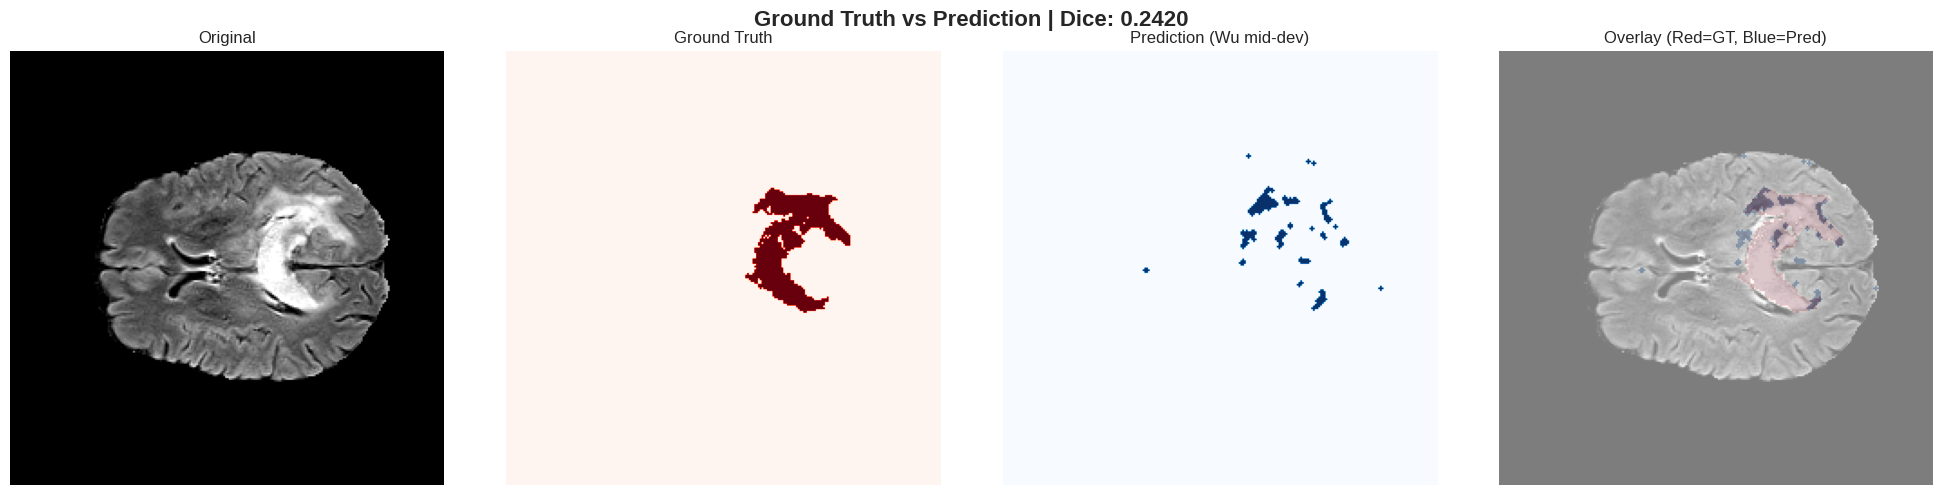

Processing patients:  90%|█████████ | 18/20 [00:13<00:01,  1.34it/s]


Evaluation for BraTS20_Training_019 | Slice 80

Dice (DSC):            0.0052
IoU (Jaccard):         0.0026
NSD (tol=1.0 vox): 0.0351


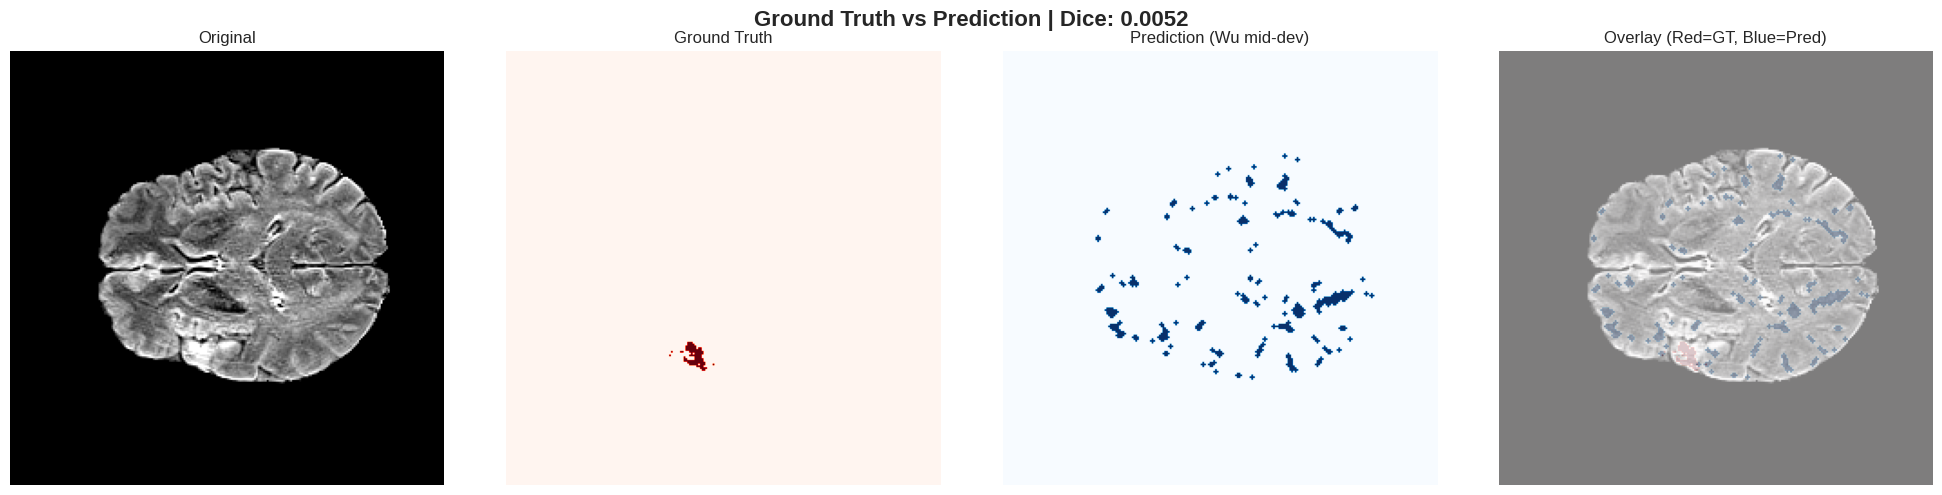

Processing patients:  95%|█████████▌| 19/20 [00:14<00:00,  1.34it/s]


Evaluation for BraTS20_Training_020 | Slice 67

Dice (DSC):            0.3900
IoU (Jaccard):         0.2423
NSD (tol=1.0 vox): 0.3007


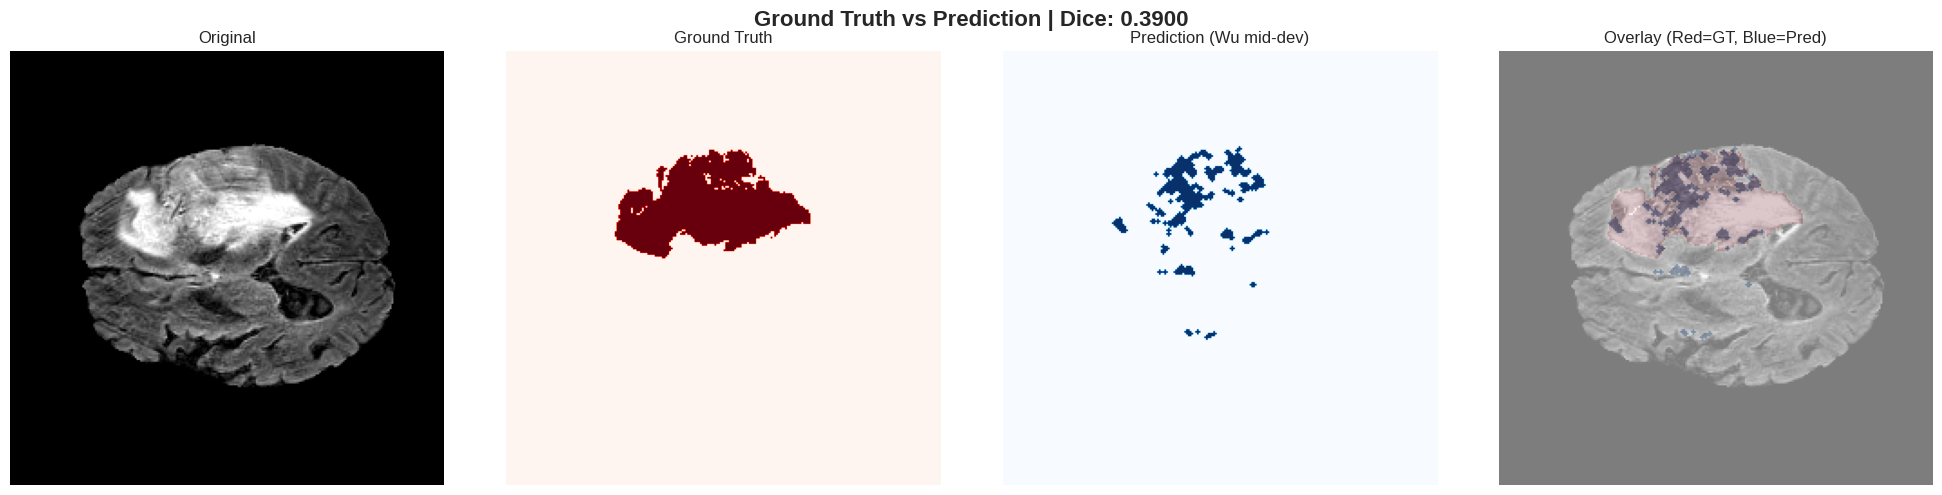

Processing patients: 100%|██████████| 20/20 [00:15<00:00,  1.28it/s]


Processing complete.
Successful cases: 20
Failures / no GT: 0


,patient_id,slice_idx,tumor_area,dice,iou,nsd,inference_time_s,num_params,gflops,status
0,BraTS20_Training_001,75,2841,0.098201,0.051636,0.228637,0.135463,0,NaN,success
1,BraTS20_Training_002,66,1781,0.359597,0.219213,0.252809,0.161430,0,NaN,success
2,BraTS20_Training_003,78,2098,0.000000,0.000000,0.056436,0.145830,0,NaN,success
3,BraTS20_Training_004,65,1567,0.034087,0.017339,0.112700,0.185011,0,NaN,success
4,BraTS20_Training_005,72,1781,0.000000,0.000000,0.000000,0.160679,0,NaN,success
5,BraTS20_Training_006,75,1883,0.052224,0.026812,0.182010,0.150272,0,NaN,success
6,BraTS20_Training_007,81,750,0.000000,0.000000,0.037288,0.146583,0,NaN,success
7,BraTS20_Training_008,72,3361,0.000000,0.000000,0.000000,0.147457,0,NaN,success
8,BraTS20_Training_009,82,2032,0.082034,0.042771,0.207239,0.144575,0,NaN,success
9,BraTS20_Training_010,77,1510,0.087219,0.045598,0.138945,0.165706,0,NaN,success


In [37]:
def batch_process_patients(patient_dirs, num_patients: int = 20, nsd_tolerance: float = 1.0):

    
    segmenter = WuKMeansBraTSSegmentation(n_clusters=3)
    
    records = []

    
    for patient_dir in tqdm(patient_dirs[:num_patients], desc="Processing patients"):
        
        patient_id = patient_dir.name
        
        flair_path = patient_dir / f"{patient_id}_flair.nii"

        if not flair_path.exists():
            continue

        try:
            results = segmenter.segment_slice(str(flair_path))
            
            eval_results = evaluate_segmentation(patient_dir, results,
                                                 nsd_tolerance=nsd_tolerance)

            
            if eval_results is None:
                
                status = "no_gt"
                
                dice = iou = nsd = np.nan
                
            else:
                status = "success"
                
                dice = eval_results["dice"]
                
                iou = eval_results["iou"]
                
                nsd = eval_results["nsd"]

            

            record = {
                "patient_id": patient_id,
                "slice_idx": results["slice_idx"],
                "tumor_area": results["tumor_area"],
                "dice": dice,
                "iou": iou,
                "nsd": nsd,
                "inference_time_s": results["inference_time"],
                "num_params": results["num_params"],
                "gflops": results["gflops"],
                "status": status,
            }

        

        except Exception as e:
            record = {
                "patient_id": patient_id,
                "slice_idx": None,
                "tumor_area": np.nan,
                "dice": np.nan,
                "iou": np.nan,
                "nsd": np.nan,
                "inference_time_s": np.nan,
                "num_params": 0,
                "gflops": np.nan,
                "status": f"failed: {e}",
            }

        
        records.append(record)

    summary_df = pd.DataFrame(records)
    return summary_df




print("\nBATCH PROCESSING - Wu mid-dev (color-based K-means)\n")

summary_df = batch_process_patients(training_dirs, num_patients=20)

print("\nProcessing complete.")
print(f"Successful cases: {len(summary_df[summary_df['status'] == 'success'])}")
print(f"Failures / no GT: {len(summary_df[summary_df['status'] != 'success'])}")

display(summary_df)


STATISTICAL SUMMARY
        tumor_area       dice        iou        nsd  inference_time_s
count    20.000000  20.000000  20.000000  20.000000         20.000000
mean   1466.650000   0.141335   0.082349   0.184507          0.154513
std     875.797037   0.141796   0.087170   0.138284          0.010980
min     105.000000   0.000000   0.000000   0.000000          0.135463
25%     720.250000   0.016300   0.008227   0.078519          0.146582
50%    1538.500000   0.092710   0.048617   0.170683          0.152950
75%    1920.250000   0.247443   0.141223   0.258085          0.160866
max    3361.000000   0.390025   0.242255   0.543438          0.185011


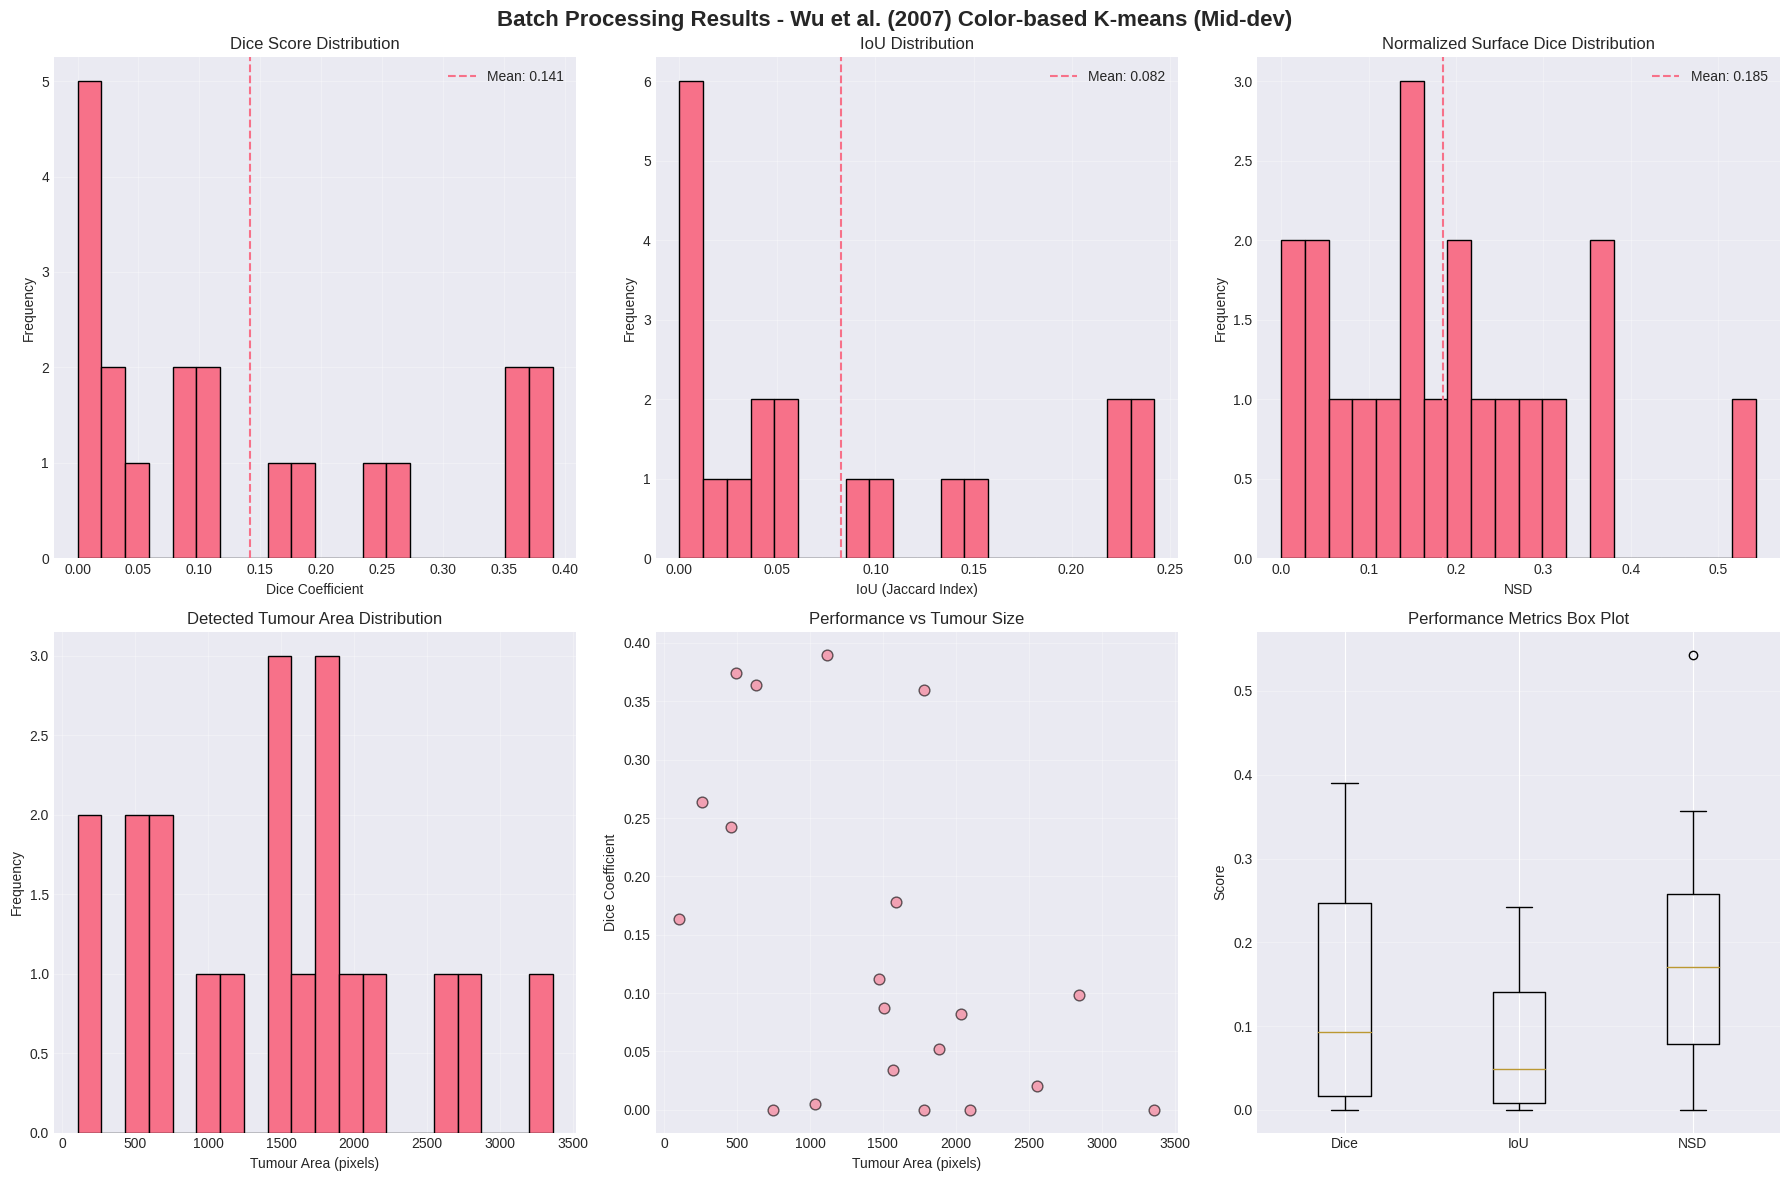


TOP 5 BEST PERFORMING PATIENTS (Highest Dice Score)



,patient_id,dice,iou,nsd,tumor_area,inference_time_s
19,BraTS20_Training_020,0.390025,0.242255,0.300692,1120,0.155411
15,BraTS20_Training_016,0.374551,0.230429,0.543438,491,0.163635
14,BraTS20_Training_015,0.363636,0.222222,0.354887,631,0.146579
1,BraTS20_Training_002,0.359597,0.219213,0.252809,1781,0.161430
12,BraTS20_Training_013,0.263784,0.151930,0.204846,263,0.153156



TOP 5 WORST PERFORMING PATIENTS (Lowest Dice Score)



,patient_id,dice,iou,nsd,tumor_area,inference_time_s
2,BraTS20_Training_003,0.000000,0.000000,0.056436,2098,0.145830
4,BraTS20_Training_005,0.000000,0.000000,0.000000,1781,0.160679
6,BraTS20_Training_007,0.000000,0.000000,0.037288,750,0.146583
7,BraTS20_Training_008,0.000000,0.000000,0.000000,3361,0.147457
18,BraTS20_Training_019,0.005249,0.002632,0.035054,1036,0.152745


In [38]:
successful = summary_df[summary_df["status"] == "success"].copy()


required_cols = {"dice", "iou", "nsd"}



if not successful.empty and required_cols.issubset(successful.columns):


    # Summary statistics

    print("STATISTICAL SUMMARY")

    summary_cols = ["tumor_area", "dice", "iou", "nsd", "inference_time_s"]
    
    existing_summary_cols = [c for c in summary_cols if c in successful.columns]
    
    print(successful[existing_summary_cols].describe())

    

   
    # Visualisation

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    fig.suptitle(
        
        "Batch Processing Results - Wu et al. (2007) Color-based K-means (Mid-dev)",
        fontsize=16,
        
        fontweight="bold",
        
    )


    # Dice score distribution
    axes[0, 0].hist(successful["dice"].dropna(), bins=20, edgecolor="black")
    
    axes[0, 0].axvline(successful["dice"].mean(), linestyle="--",
                       label=f"Mean: {successful['dice'].mean():.3f}")
    
    axes[0, 0].set_xlabel("Dice Coefficient")
    
    axes[0, 0].set_ylabel("Frequency")
    
    axes[0, 0].set_title("Dice Score Distribution")
    
    axes[0, 0].legend()
    
    axes[0, 0].grid(True, alpha=0.3)

    

    # IoU distribution
    axes[0, 1].hist(successful["iou"].dropna(), bins=20, edgecolor="black")
    
    axes[0, 1].axvline(successful["iou"].mean(), linestyle="--",
                       label=f"Mean: {successful['iou'].mean():.3f}")
    
    axes[0, 1].set_xlabel("IoU (Jaccard Index)")
    
    axes[0, 1].set_ylabel("Frequency")
    
    axes[0, 1].set_title("IoU Distribution")
    
    axes[0, 1].legend()
    
    axes[0, 1].grid(True, alpha=0.3)

    

    # NSD distribution
    axes[0, 2].hist(successful["nsd"].dropna(), bins=20, edgecolor="black")
    
    axes[0, 2].axvline(successful["nsd"].mean(), linestyle="--",
                       label=f"Mean: {successful['nsd'].mean():.3f}")
    
    axes[0, 2].set_xlabel("NSD")
    
    axes[0, 2].set_ylabel("Frequency")
    
    axes[0, 2].set_title("Normalized Surface Dice Distribution")
    
    axes[0, 2].legend()
    
    axes[0, 2].grid(True, alpha=0.3)


    
    # Tumour area distribution
    axes[1, 0].hist(successful["tumor_area"].dropna(), bins=20, edgecolor="black")
    
    axes[1, 0].set_xlabel("Tumour Area (pixels)")
    
    axes[1, 0].set_ylabel("Frequency")
    
    axes[1, 0].set_title("Detected Tumour Area Distribution")
    
    axes[1, 0].grid(True, alpha=0.3)



    # Dice vs tumour area
    axes[1, 1].scatter(
        
        successful["tumor_area"],
        
        successful["dice"],
        
        alpha=0.6,
        
        s=60,
        
        edgecolors="black",
        
    )

    
    axes[1, 1].set_xlabel("Tumour Area (pixels)")
    
    axes[1, 1].set_ylabel("Dice Coefficient")
    
    axes[1, 1].set_title("Performance vs Tumour Size")
    
    axes[1, 1].grid(True, alpha=0.3)


    
    # Box plot of core metrics
    metric_names = ["dice", "iou", "nsd"]
    
    metric_data = [successful[m].dropna() for m in metric_names]
    
    axes[1, 2].boxplot(metric_data, labels=["Dice", "IoU", "NSD"])
    
    axes[1, 2].set_ylabel("Score")
    
    axes[1, 2].set_title("Performance Metrics Box Plot")
    
    axes[1, 2].grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


    

    # Best and worst cases (by Dice)
    
    print("\nTOP 5 BEST PERFORMING PATIENTS (Highest Dice Score)\n")

    display(
        
        successful.nlargest(5, "dice")[
        
            ["patient_id", "dice", "iou", "nsd", "tumor_area", "inference_time_s"]
        
        ]
    )


    

    print("\nTOP 5 WORST PERFORMING PATIENTS (Lowest Dice Score)\n")

    display(
        
        successful.nsmallest(5, "dice")[
        
            ["patient_id", "dice", "iou", "nsd", "tumor_area", "inference_time_s"]
        
        ]
    )

else:
    print("No successful runs with the required metrics (dice, iou, nsd).")
